# Interventional influence map — the controlled experiment

Every other analysis in this project infers dependence from observed
co-movement, which is why seasonality, drift, regime mixture and
self-predictability kept confounding it. Here **we set the cause**: a flat
network, one node perturbed at a time, response measured everywhere. The
response *is* the effect — no inference, no null hypothesis, no confound.

**What this produces.** `d(response_j)/d(demand_i)` for every perturbed node
*i* and target *j*. EPANET's simulation is quasi-static, so a flat network
sits at one steady state and a perturbation moves it to another. There is no
transport lag to find: this is a **Jacobian, not a dynamic response**, and
`duration=0` is the correct simulation — one solve, tanks pinned at initial
level. Running longer would let tanks cycle and reintroduce the drift this
design removes.

**Two results that decide how everything downstream must be read**, both
verified on hand-built networks before running here:

| quantity | property | usable for |
|---|---|---|
| pressure `dP_j/dD_i` | **symmetric** (Maxwell–Betti reciprocity) | coupling **strength** only |
| flow `dQ_p/dD_i` | **asymmetric** — a routing matrix | **direction** (who supplies whom) |

Pressure influence can never yield direction; that is a theorem about
resistive networks, not a property of this dataset. Direction comes from
flows, because a downstream district's demand loads the upstream district's
mains while the reverse never happens.

**Scope.** This is a diagnostic world, not an FL dataset — flat consumption
removes the regime signal the thesis is about. Use it to validate the
observational statistics and to place sensors, then go back to the drift
worlds to learn.

In [1]:
import sys, pathlib, copy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr, yaml

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
import sensitivity_probe as S

INP       = PROJ / "data/01_raw/D_Town.inp" # Graeme
DISTRICTS = yaml.safe_load((PROJ / "data/01_raw/districts_dtown.yml").read_text())
BASE      = yaml.safe_load((PROJ / "conf/base/parameters.yml").read_text())
ANCHOR    = BASE["hydraulics"]["anchor_scale"]
DEMAND_MULT = BASE["hydraulics"]["demand_multiplier"]   # Graeme.inp ships 0.2!

wn_raw = wntr.network.WaterNetworkModel(str(INP))
print(f"{len(wn_raw.junction_name_list)} junctions | {len(wn_raw.pipe_name_list)} pipes | "
      f"{len(wn_raw.tank_name_list)} tanks | {len(wn_raw.reservoir_name_list)} reservoirs")
pd.set_option("display.width", 160)

399 junctions | 443 pipes | 7 tanks | 1 reservoirs


c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py:2082: UserWarning: Not all curves were used in "C:\Users\arthu\USPy\10_Mestrado\fedWater\data\01_raw\D_Town.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


## 1. Flat baseline

Patterns are stripped rather than flattened, so nothing downstream can
reintroduce a diurnal shape. `anchor_scale` matches `conf/base` so the
operating point is the one the rest of the project runs at — the Jacobian is
only valid near the baseline it is measured at.

In [2]:
print("inp global demand multiplier:", wn_raw.options.hydraulic.demand_multiplier,
      "-> pinning to", DEMAND_MULT)
flat = S.flat_baseline(wn_raw, anchor_scale=ANCHOR, demand_multiplier=DEMAND_MULT)
d0 = S.node_demands(flat)
print(f"demand: total {d0.sum():.4f} m3/s | mean {d0.mean():.6f} | "
      f"zero-demand junctions {(d0 == 0).sum()}")
print("source links:", S.source_links(flat)[:6], "...")

inp global demand multiplier: 1.0 -> pinning to 1.0
demand: total 0.0211 m3/s | mean 0.000053 | zero-demand junctions 51
source links: [('P1044', 1.0), ('P144', -1.0), ('P15', -1.0), ('P215', -1.0), ('P316', 1.0), ('P347', -1.0)] ...


In [3]:
flat.query_node_attribute("base_demand").describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
0,399.0,0.000053,0.00004,0.0,0.000019,0.000051,0.000085,0.000315


### SC-1 — is the flat world actually flat?

Tanks integrate net inflow, so a constant-demand network can still drift as
they fill and drain. The `duration=0` Jacobian is valid regardless (tanks are
pinned there), but if this reports `flat=False`, no *time-series* reading of
this world is trustworthy.

In [4]:
display(S.check_baseline_flat(flat, n_steps=48))

,n_tanks,n_steps,flow_cv,pressure_range_med,flat
0,7,49,0.789673,8.845352,False


## 2. The sweep

Perturbations are **additive**, not multiplicative: it keeps the magnitude
identical across nodes (a true partial derivative, comparable entries) and it
still works for the many junctions whose base demand is zero, which a
multiplier would leave untouched. Three levels, so nonlinearity is measured
rather than assumed away.

In [6]:
mean_d = float(d0[d0 > 0].mean())
DELTAS = [0.5 * mean_d, 1.0 * mean_d, 2.0 * mean_d]     # low / medium / high
# DELTAS = [100.5 * mean_d, 10.0 * mean_d, 5.0 * mean_d]  
print("deltas (m3/s):", [round(x, 6) for x in DELTAS])

sweep, diag = S.perturbation_sweep(flat, DELTAS, verbose=True)
print(f"\nsolves {len(diag)} | infeasible {int((~diag.feasible).sum())} | "
      f"rows {len(sweep)}")
display(diag.groupby("kind")["feasible"].agg(["count", "mean"]))

deltas (m3/s): [3e-05, 6.1e-05, 0.000121]
  20/399 nodes
  40/399 nodes
  60/399 nodes
  80/399 nodes
  100/399 nodes
  120/399 nodes
  140/399 nodes
  160/399 nodes
  180/399 nodes
  200/399 nodes
  220/399 nodes
  240/399 nodes
  260/399 nodes
  280/399 nodes
  300/399 nodes
  320/399 nodes
  340/399 nodes
  360/399 nodes
  380/399 nodes

solves 1198 | infeasible 0 | rows 1036602


,count,mean
kind,,
baseline,1,1.0
perturbed,1197,1.0


### SC-2 — physics checks

- **Mass balance**: every added m³/s must reappear at the sources. A hard
  constraint that catches any sign or bookkeeping error.
- **Diagonal dominance**: perturbing node *i* must move *i*'s own pressure
  most. Ties are expected and physical (a node just below the source raises
  head loss only in the supply main, so everything downstream drops
  equally), so the test is weak dominance within 1%.
- **Reciprocity**: `dP_j/dD_i == dP_i/dD_j`. If this fails the solver is
  wrong; if it passes, pressure cannot give direction.

In [7]:
mb = S.check_mass_balance(sweep, flat)
print(f"mass balance  max rel error {mb.rel_error.max():.2e}  "
      f"(EPANET reports to finite precision; <1e-4 is exact)")
if mb.rel_error.max() > 1e-4:
    print("  ^ a CONSTANT relative error means a global scaling is being "
          "applied that the sweep does not know about -- check "
          "options.hydraulic.demand_multiplier first.")

dd = S.check_diagonal_dominance(sweep)
print(f"diagonal dominance  self_is_max {dd.self_is_max.mean():.3f}  "
      f"min self/max {dd.self_frac_of_max.min():.3f}")

display(S.check_reciprocity(sweep, flat, delta=DELTAS[1]))

mass balance  max rel error 2.32e-03  (EPANET reports to finite precision; <1e-4 is exact)
  ^ a CONSTANT relative error means a global scaling is being applied that the sweep does not know about -- check options.hydraulic.demand_multiplier first.
diagonal dominance  self_is_max 0.933  min self/max 0.000


,n_nodes,max_abs_asymmetry,max_abs_sensitivity,relative_asymmetry,symmetric
0,399,249.238571,1531.521973,0.162739,False


### SC-3 — how far does the linear map extrapolate?

Head loss goes as ~Q^1.85, so responses do not superpose. `ratio_median`
near 1.0 means sensitivity is stable between the smallest and largest
perturbation; departures are the honest bound on extrapolation.

In [8]:
for q in ("flowrate", "pressure"):
    display(S.check_linearity(sweep, q))

,quantity,delta_lo,delta_hi,n_pairs,ratio_median,ratio_p05,ratio_p95,max_abs_dev_from_1
0,flowrate,0.00003,0.000121,96945,0.999872,0.25,1.155769,14822.583984


,quantity,delta_lo,delta_hi,n_pairs,ratio_median,ratio_p05,ratio_p95,max_abs_dev_from_1
0,pressure,0.00003,0.000121,122052,1.0,0.625,1.25,1.625


## 3. Coupling strength (pressure — symmetric)

In [9]:
M = S.district_influence(sweep, DISTRICTS, flat, "pressure", delta=DELTAS[1])
display(M.round(3))
display(S.influence_asymmetry(M).round(4))
print("asymmetry_ratio ~1.0 everywhere is RECIPROCITY, not a null result.")

display(S.cross_district_leakage(sweep, DISTRICTS, "pressure", delta=DELTAS[1]))

d_tgt,District_A,District_B,District_C,District_D,District_E
d_src,,,,,
District_A,38.390999,3.172000,0.294000,3.325000,2.952000
District_B,3.155000,606.104004,0.767000,0.208000,0.188000
District_C,0.397000,1.075000,68.949997,0.030000,0.026000
District_D,3.322000,0.225000,0.020000,209.904999,3.491000
District_E,2.956000,0.201000,0.017000,3.495000,301.502014


,district_a,district_b,infl_a_to_b,infl_b_to_a,dominant_direction,asymmetry_ratio,coupling_strength
0,District_A,District_B,3.1716,3.1552,District_A->District_B,1.0052,3.1634
1,District_A,District_C,0.2944,0.3968,District_C->District_A,0.7420,0.3456
2,District_A,District_D,3.3245,3.3220,District_A->District_D,1.0008,3.3232
3,District_A,District_E,2.9516,2.9559,District_E->District_A,0.9986,2.9538
4,District_B,District_C,0.7666,1.0749,District_C->District_B,0.7132,0.9207
5,District_B,District_D,0.2077,0.2252,District_D->District_B,0.9223,0.2165
6,District_B,District_E,0.1879,0.2007,District_E->District_B,0.9367,0.1943
7,District_C,District_D,0.0302,0.0199,District_C->District_D,1.5194,0.0251
8,District_C,District_E,0.0256,0.0170,District_C->District_E,1.5114,0.0213
9,District_D,District_E,3.4912,3.4951,District_E->District_D,0.9989,3.4932


asymmetry_ratio ~1.0 everywhere is RECIPROCITY, not a null result.


,within_district,between_district,ratio
0,93.592361,1.467483,63.777458


## 4. Direction (flow — the supply map)

`D[A, B]` = the fraction of district B's demand increment that transits
district A's internal pipes. Read as **"B is supplied through A"**, so A is
upstream of B. 1.0 = all of B's water crosses A; 0.0 = none does.

Pairs whose two directions agree within 2% are reported as
`mutual/parallel` rather than forced into a direction — in a looped network
that is a real configuration, not a failure to decide.

In [10]:
D = S.supply_dependency(sweep, DISTRICTS, flat, delta=DELTAS[1])
display(D.round(3))

dp = S.directed_pairs(D)
display(dp.round(4))

demand_of,District_A,District_B,District_C,District_D,District_E
transits_through,,,,,
District_A,1.000,0.087,0.023,0.362,0.193
District_B,0.013,1.000,0.002,0.001,0.000
District_C,0.014,0.009,1.000,0.001,0.000
District_D,0.069,0.001,0.000,1.000,0.016
District_E,0.051,0.000,0.000,0.022,1.000


,district_a,district_b,b_transits_a,a_transits_b,verdict,asymmetry,coupled
0,District_A,District_B,0.0867,0.0129,District_A upstream of District_B,0.0738,True
1,District_A,District_C,0.0228,0.0142,District_A upstream of District_C,0.0087,True
2,District_A,District_D,0.3621,0.0688,District_A upstream of District_D,0.2933,True
3,District_A,District_E,0.1934,0.0508,District_A upstream of District_E,0.1426,True
4,District_B,District_C,0.0023,0.0093,District_C upstream of District_B,0.0071,True
5,District_B,District_D,0.0006,0.0007,District_D upstream of District_B,0.0000,True
6,District_B,District_E,0.0004,0.0004,District_E upstream of District_B,0.0001,True
7,District_C,District_D,0.0007,0.0002,District_C upstream of District_D,0.0006,True
8,District_C,District_E,0.0004,0.0001,District_C upstream of District_E,0.0003,True
9,District_D,District_E,0.0163,0.0224,District_E upstream of District_D,0.0061,True


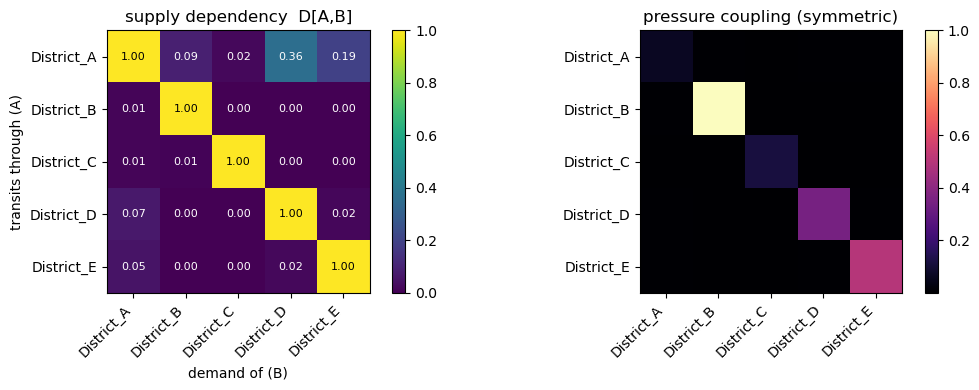

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(D.to_numpy(), cmap="viridis", vmin=0, vmax=1)
ax[0].set_xticks(range(len(D.columns))); ax[0].set_xticklabels(D.columns, rotation=45, ha="right")
ax[0].set_yticks(range(len(D.index)));   ax[0].set_yticklabels(D.index)
ax[0].set_xlabel("demand of (B)"); ax[0].set_ylabel("transits through (A)")
ax[0].set_title("supply dependency  D[A,B]")
for i in range(len(D.index)):
    for j in range(len(D.columns)):
        ax[0].text(j, i, f"{D.iloc[i,j]:.2f}", ha="center", va="center",
                   color="w" if D.iloc[i,j] < .6 else "k", fontsize=8)
fig.colorbar(im, ax=ax[0], fraction=.046)

Mn = M.to_numpy() / np.nanmax(M.to_numpy())
im2 = ax[1].imshow(Mn, cmap="magma")
ax[1].set_xticks(range(len(M.columns))); ax[1].set_xticklabels(M.columns, rotation=45, ha="right")
ax[1].set_yticks(range(len(M.index)));   ax[1].set_yticklabels(M.index)
ax[1].set_title("pressure coupling (symmetric)")
fig.colorbar(im2, ax=ax[1], fraction=.046)
fig.tight_layout(); plt.show()

## 5. Node-level map

The full `dQ/dD` matrix is the routing structure of the network: which pipes
carry which node's water, and in what fraction when parallel paths exist.

flow sensitivity matrix: (399, 459)
fraction of exactly-zero entries: 0.452


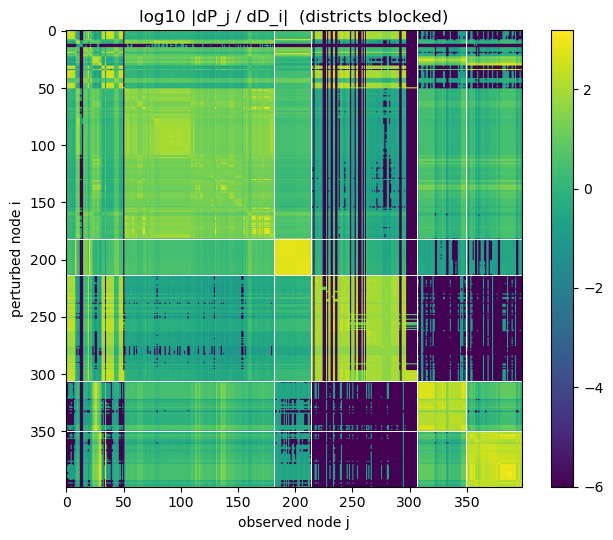

In [12]:
Qm = S.influence_matrix(sweep, "flowrate", delta=DELTAS[1])
print("flow sensitivity matrix:", Qm.shape)
print("fraction of exactly-zero entries:", float((Qm.abs() < 1e-9).mean().mean().round(3)))

n2d = {n: d for d, nodes in DISTRICTS["districts"].items() for n in nodes}
Pm = S.influence_matrix(sweep, "pressure", delta=DELTAS[1])
order = sorted([n for n in Pm.index if n in Pm.columns], key=lambda n: (n2d.get(n, ""), n))
Pm = Pm.loc[order, order]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(np.log10(Pm.abs() + 1e-6), cmap="viridis")
bounds, prev = [], None
for k, n in enumerate(order):
    if n2d.get(n) != prev:
        bounds.append(k); prev = n2d.get(n)
for b in bounds[1:]:
    ax.axhline(b - .5, c="w", lw=.7); ax.axvline(b - .5, c="w", lw=.7)
ax.set_title("log10 |dP_j / dD_i|  (districts blocked)")
ax.set_xlabel("observed node j"); ax.set_ylabel("perturbed node i")
fig.colorbar(im, fraction=.046); fig.tight_layout(); plt.show()

## 6. Ground truth for the observational work

This map is what the rest of the project was trying to estimate, so it can
now be used to score those methods rather than scoring them against
adjacency — a coarse binary proxy — as before.

In [13]:
gtb = None
gt_path = PROJ / "data/03_primary/gt_boundaries.csv"
if gt_path.exists():
    gtb = pd.read_csv(gt_path, dtype={"pipe": str})
    ds = sorted(DISTRICTS["districts"])
    adj = set()
    for _, r in gtb.iterrows():
        if not r.get("closed", False):
            adj.add((min(r.district_a, r.district_b), max(r.district_a, r.district_b)))
    rows = []
    for i, a in enumerate(ds):
        for b in ds[i+1:]:
            rows.append(dict(district_a=a, district_b=b,
                             adjacent=(a, b) in adj,
                             pressure_coupling=float(M.loc[a, b]),
                             supply_max=float(max(D.loc[a, b], D.loc[b, a]))))
    cmp = pd.DataFrame(rows)
    display(cmp.round(4))
    print("\nAdjacency is a BINARY proxy; these columns are the graded truth. "
          "Pairs that are non-adjacent yet strongly coupled are exactly what "
          "the AUROC label could not represent.")
else:
    print("gt_boundaries.csv not found -- run the pipeline once, or skip.")

,district_a,district_b,adjacent,pressure_coupling,supply_max
0,District_A,District_B,True,3.1716,0.0867
1,District_A,District_C,True,0.2944,0.0228
2,District_A,District_D,False,3.3245,0.3621
3,District_A,District_E,False,2.9516,0.1934
4,District_B,District_C,True,0.7666,0.0093
5,District_B,District_D,False,0.2077,0.0007
6,District_B,District_E,False,0.1879,0.0004
7,District_C,District_D,True,0.0302,0.0007
8,District_C,District_E,False,0.0256,0.0004
9,District_D,District_E,True,3.4912,0.0224



Adjacency is a BINARY proxy; these columns are the graded truth. Pairs that are non-adjacent yet strongly coupled are exactly what the AUROC label could not represent.


## 7. Interactive influence explorer

Each node is perturbed **individually**, so "what does district A affect" has
no single answer — it depends on how you collapse ~23 separate experiments.
The aggregator dropdown changes the question:

| aggregator | question |
|---|---|
| `max` | can **any** single node here move that target? (worst case) |
| `mean_all` | district-average influence — but unaffected targets count as 0, so it conflates *weakly* coupled with *rarely* coupled |
| `mean_changed` | when it does couple, by how much? **Read with `frac_changed`, never alone** |
| `frac_changed` / `n_changed` | breadth instead of depth |
| `sum` | total if every node were perturbed — extensive, so **not comparable across districts of different size** |

The perturbed district is outlined in cyan rather than shaded, and
"hide own district" is on by default: self-influence is always the largest
and would otherwise flatten the colour scale and hide the cross-district
structure that is the actual point.

In [ ]:
S.influence_explorer(sweep, flat, DISTRICTS)

### Static panel — all districts, one aggregator

For the write-up, where a widget can't go.

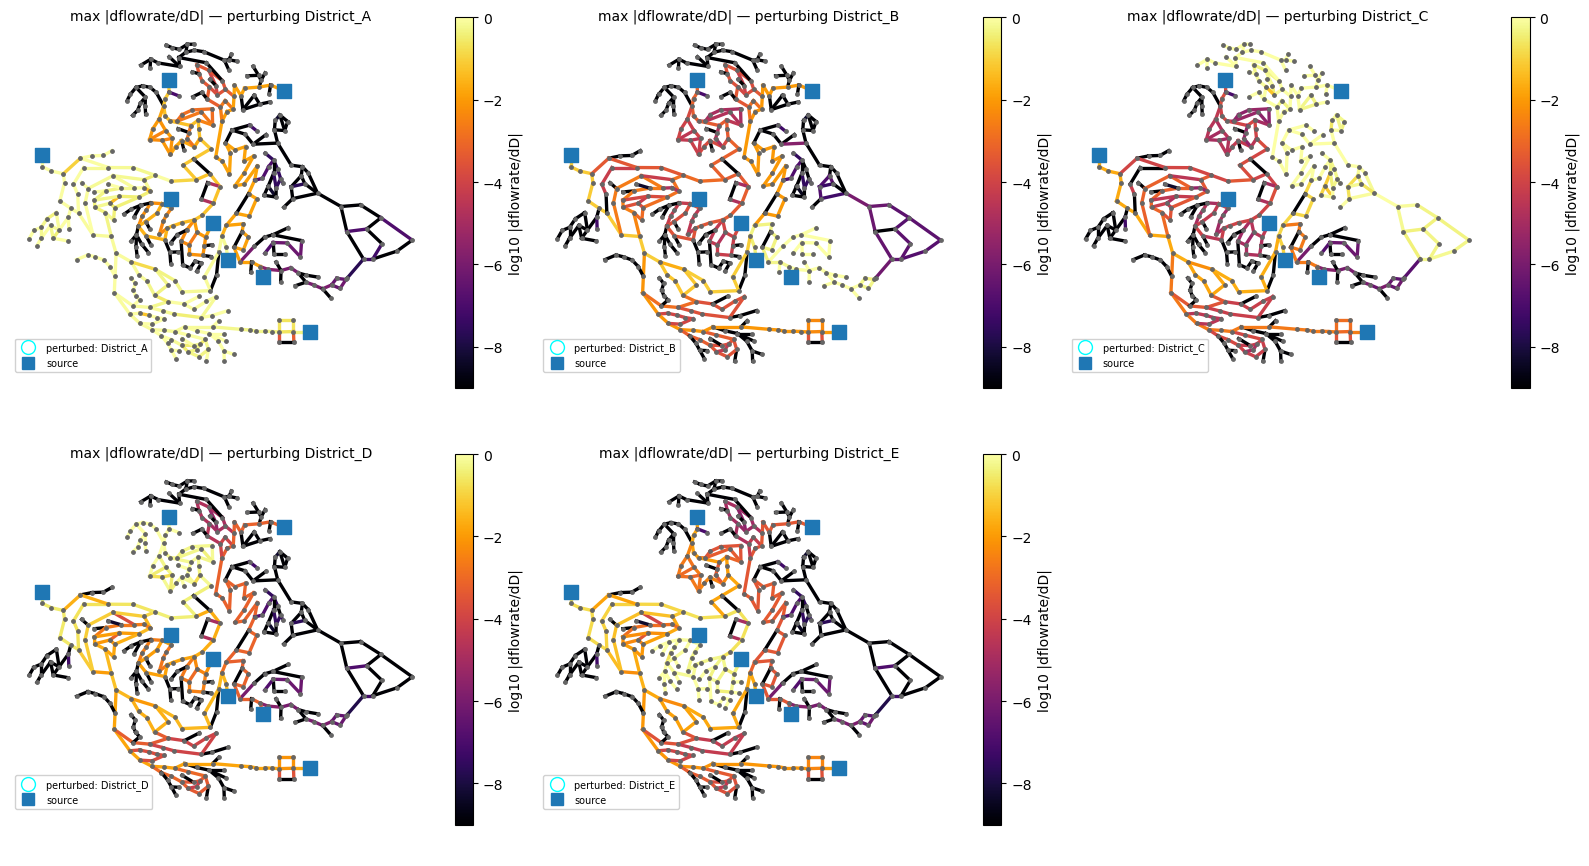

In [15]:
HOW, LOG = "max", True
ds = sorted(DISTRICTS["districts"])
n2d = {n: d for d, nn in DISTRICTS["districts"].items() for n in nn}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, src in zip(axes.ravel(), ds):
    vals = S.aggregate_response(sweep, DISTRICTS, src, quantity="flowrate",
                                delta=DELTAS[1], how=HOW)
    vals = vals[[n2d.get(i) != src for i in vals.index]]      # hide own
    S.plot_network_influence(flat, DISTRICTS, vals, source=src,
                             quantity="flowrate", how=HOW, log=LOG, ax=ax)
for ax in axes.ravel()[len(ds):]:
    ax.axis("off")
fig.tight_layout(); plt.show()

### Breadth vs depth

`frac_changed` and `mean_changed` answer different questions and can
disagree sharply: a district may touch every node weakly (high breadth, low
depth) or a handful strongly. Plotting them together is the honest summary.

aggregator,frac_changed,max,mean_all,mean_changed
source,,,,
District_A,0.5188,18.2722,2.8233,3.1403
District_B,0.5778,6.0190,5.2413,5.1841
District_C,0.2778,21.7443,9.7679,10.1913
District_D,0.4238,10.5463,3.4084,3.6404
District_E,0.3002,9.4958,5.1066,5.5009


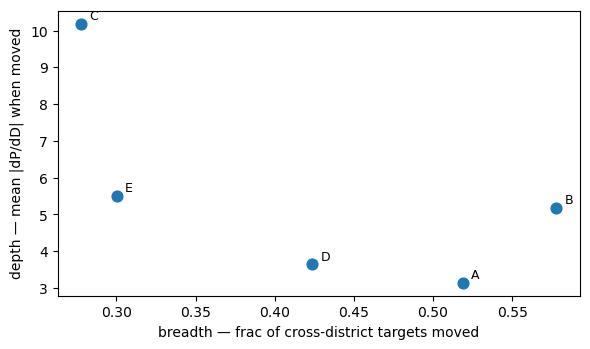

In [16]:
rows = []
for src in ds:
    for how in ("max", "mean_all", "mean_changed", "frac_changed"):
        v = S.aggregate_response(sweep, DISTRICTS, src, quantity="pressure",
                                 delta=DELTAS[1], how=how, threshold=1e-3)
        v = v[[n2d.get(i) != src for i in v.index]]
        rows.append(dict(source=src, aggregator=how, mean=float(v.mean()),
                         max=float(v.max())))
agg = pd.DataFrame(rows)
display(agg.pivot(index="source", columns="aggregator", values="mean").round(4))

fig, ax = plt.subplots(figsize=(6, 3.6))
b = agg[agg.aggregator == "frac_changed"].set_index("source")["mean"]
d = agg[agg.aggregator == "mean_changed"].set_index("source")["mean"]
ax.scatter(b, d, s=60)
for k in b.index:
    ax.annotate(k.replace("District_", ""), (b[k], d[k]),
                textcoords="offset points", xytext=(6, 3), fontsize=9)
ax.set_xlabel("breadth — frac of cross-district targets moved")
ax.set_ylabel("depth — mean |dP/dD| when moved")
fig.tight_layout(); plt.show()

## 8. What to do with this

- **Score the observational statistics properly.** Replace the binary
  adjacency label with `pressure_coupling` (strength) and `D` (direction).
  Spearman of `partial_rv` against `pressure_coupling` is the honest version
  of the AUROC we were computing.
- **Settle the direction question.** `directed_pairs` is the physical answer
  Granger could not produce. Compare it with the Granger verdicts from the
  observational notebook: agreement above chance would be a real finding,
  and the earlier evidence says it will not be.
- **Place sensors against measured influence** instead of topology proxies.
  The candidate that observes the most influence mass, with least redundancy,
  is now computable directly rather than approximated by `carry` and
  `d_boundary`.
- **Controls worth adding**: rerun on the `isolated` variant — cross-district
  influence must collapse to ~0, which is a strong negative control on the
  whole apparatus.

**Limits to state plainly**: one operating point, one network, static; valid
near this baseline only, with the departure bounded by SC-3. Nonlinearity
means the map should be re-measured if `anchor_scale` or the consumption
level changes materially.

## 9. Attributing observed similarity to the network

`reduction_pct` is the answer to "how much of this similarity is plumbing".
Both sides must be measured on the same objects: the observed statistic on
flow sensors is compared against the Jacobian restricted to those same
pipes, weighted by real per-node demand variability.

Use `pearson` as `obs_col`. `rho_hydraulic` is a correlation, so the ratio
is only apples-to-apples against another correlation -- `partial_rv` is an
RV coefficient on matrices and is not comparable this way.


In [18]:
# ---- observed similarity, from the SAME placement/quantity as the probe ----
import placement_poc as P

WORLD = P.discover_worlds(PROJ).query("usable and variant == 'baseline'").iloc[0]
art   = P.load_world(WORLD["dir"])

cands  = P.candidate_table(art["wn"], art["districts"])
feats, dist = P.topology_features(art["wn"], art["districts"], cands)
stats  = P.residual_stats(art["pressures"], art["flows"], cands, art["steps_day"])
pls    = P.strategies(cands, feats, stats, dist, art["params"], seed=0)

PLACEMENT, KIND, METHOD = "variance", "flow", "pearson"
placement = pls[PLACEMENT]

ss = P.build_series(art["pressures"], art["flows"], placement)
ss = ss[ss["kind"] == KIND]
mats, sigs = P.district_data(ss, art["steps_day"])
scores = P.pair_scores(mats, sigs, n_sur=99, seed=0)

observed = (scores[(scores.kind == KIND) & (scores.method == METHOD)]
            [["district_a", "district_b", "statistic"]])

# sensor names must match the probe's target namespace: LINK names for flow
sensors = {d: list(cfg[KIND]) for d, cfg in placement.items()}

# real per-node demand variability, not the uniform default
dem_path = PROJ / "data/02_intermediate/demand.parquet"
demand_std = None
if dem_path.exists():
    dem = pd.read_parquet(dem_path)
    demand_std = dem[[c for c in dem.columns if c != "month"]].std()

att = S.similarity_attribution(
    sweep, DISTRICTS, observed, sensors=sensors,
    quantity="flowrate" if KIND == "flow" else "pressure",
    delta=DELTAS[1], demand_std=demand_std, obs_col="statistic")

display(att.round(4).sort_values("reduction_pct", ascending=False))
print(f"\nmedian share of observed {METHOD} explained by hydraulics alone: "
      f"{att.reduction_pct.median():.1f}%")


,district_a,district_b,rho_observed,rho_hydraulic,excess,attributable_frac,reduction_pct
0,District_A,District_B,0.7978,NaN,NaN,NaN,NaN
1,District_A,District_C,0.7850,NaN,NaN,NaN,NaN
2,District_A,District_D,0.6024,NaN,NaN,NaN,NaN
3,District_A,District_E,0.3549,NaN,NaN,NaN,NaN
4,District_B,District_C,0.9549,NaN,NaN,NaN,NaN
5,District_B,District_D,0.8168,NaN,NaN,NaN,NaN
6,District_B,District_E,0.5179,NaN,NaN,NaN,NaN
7,District_C,District_D,0.8774,NaN,NaN,NaN,NaN
8,District_C,District_E,0.5342,NaN,NaN,NaN,NaN
9,District_D,District_E,0.6199,NaN,NaN,NaN,NaN



median share of observed pearson explained by hydraulics alone: nan%


## 10. Two diagnostics on the attribution

**(1)** `demand_std` fails silently to uniform weights if `demand.parquet` is
absent -- and weighting moves `rho_hydraulic` materially, so which case you
are in has to be checked rather than assumed.

**(2)** `rho_hydraulic` comes from the probe and is FIXED. Only the observed
side is reprocessed here -- raw, deseasonalized, month-aware deseasonalized.
Deseasonalization removes the demand-side common mode, which is roughly the
assumption `rho_hydraulic` encodes, so residual correlations *should* look
almost purely hydraulic. If `raw` drives `rho_observed` toward 1 while
`reduction_pct` collapses, the regime signal lives in the profile that
deseasonalization discards.


In [19]:
# =====================================================================
# 1. Did demand_std actually load, and does it matter?
# =====================================================================
dem_path = PROJ / "data/02_intermediate/demand.parquet"
print("demand.parquet exists:", dem_path.exists())

demand_std = None
if dem_path.exists():
    dem  = pd.read_parquet(dem_path)
    cols = [c for c in dem.columns if c != "month"]
    demand_std = dem[cols].std()
    miss = [n for n in flat.junction_name_list if n not in demand_std.index]
    print(f"loaded std for {len(demand_std)} nodes | "
          f"min {demand_std.min():.3e}  max {demand_std.max():.3e}  "
          f"CV {demand_std.std()/demand_std.mean():.2f}")
    print(f"junctions in network but MISSING from demand.parquet: {len(miss)}"
          + (f"  -> {miss[:5]}" if miss else ""))
    if demand_std.max() == 0:
        print("  !! all-zero std -- weighting would be degenerate")
else:
    print("  !! FELL BACK TO UNIFORM WEIGHTS — rho_hydraulic below is unweighted")

# how much does the weighting actually change the answer?
QTY = "flowrate" if KIND == "flow" else "pressure"
cmp_w = None
for label, w in [("uniform", None), ("real demand_std", demand_std)]:
    if label == "real demand_std" and demand_std is None:
        continue
    h = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors,
                               quantity=QTY, delta=DELTAS[1], demand_std=w)
    h = h.rename(columns={"rho_hydraulic": label})
    cmp_w = h if cmp_w is None else cmp_w.merge(h, on=["district_a", "district_b"])
display(cmp_w.round(4))
if cmp_w.shape[1] > 3:
    d = (cmp_w["real demand_std"] - cmp_w["uniform"]).abs()
    print(f"weighting shifts rho_hydraulic by median {d.median():.4f}, "
          f"max {d.max():.4f}")

# =====================================================================
# 2. Where does the dependence live: profile or residual?
#    rho_hydraulic is FIXED (it comes from the probe). Only the
#    preprocessing of the observed side changes.
# =====================================================================
def signals_for(ss, steps_day, mode):
    """mode: 'raw' | 'deseason' (hour+weekend) | 'deseason_month'."""
    wide  = ss.pivot(index="step", columns="sensor", values="observed")
    month = ss.drop_duplicates("step").set_index("step")["month"].sort_index()
    if mode == "raw":
        resid = wide
    else:
        resid = P.deseasonalize(wide, steps_day, month,
                                month_aware=(mode == "deseason_month"))
    key = ss.drop_duplicates("sensor").set_index("sensor")[["district", "kind"]]
    mats, sigs = {}, {}
    for (d, k), grp in key.groupby(["district", "kind"]):
        c = sorted(grp.index)
        mats[(d, k)] = resid[c].to_numpy(float)
        sigs[(d, k)] = mats[(d, k)].mean(axis=1)
    return mats, sigs

hyd = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors,
                             quantity=QTY, delta=DELTAS[1],
                             demand_std=demand_std)

rows = []
for mode in ("raw", "deseason", "deseason_month"):
    m, g = signals_for(ss, art["steps_day"], mode)
    sc = P.pair_scores(m, g, n_sur=19, seed=0)
    obs = (sc[(sc.kind == KIND) & (sc.method == METHOD)]
           [["district_a", "district_b", "statistic"]]
           .rename(columns={"statistic": "rho_observed"}))
    t = obs.merge(hyd, on=["district_a", "district_b"])
    t["reduction_pct"] = 100 * t["rho_hydraulic"] / t["rho_observed"]
    t["excess"] = t["rho_observed"] - t["rho_hydraulic"]
    rows.append(t.assign(preprocessing=mode))
comp = pd.concat(rows, ignore_index=True)

display(comp.pivot(index=["district_a", "district_b"],
                   columns="preprocessing",
                   values=["rho_observed", "reduction_pct"]).round(3))
print(comp.groupby("preprocessing")[["rho_observed", "rho_hydraulic",
                                     "excess", "reduction_pct"]]
      .median().round(3).to_string())
print("\nrho_hydraulic is identical across rows by construction — only the "
      "observed side is reprocessed. If `raw` pushes rho_observed toward 1 "
      "while reduction_pct collapses, the regime signal is in the PROFILE, "
      "not the residual, and measuring it on residuals discards it.")


demand.parquet exists: False
  !! FELL BACK TO UNIFORM WEIGHTS — rho_hydraulic below is unweighted


,district_a,district_b,uniform
0,District_A,District_B,NaN
1,District_A,District_C,NaN
2,District_A,District_D,NaN
3,District_A,District_E,NaN
4,District_B,District_C,NaN
5,District_B,District_D,NaN
6,District_B,District_E,NaN
7,District_C,District_D,NaN
8,District_C,District_E,NaN
9,District_D,District_E,NaN


rho_observed                       reduction_pct                   
preprocessing             deseason deseason_month    raw      deseason deseason_month raw
district_a district_b                                                                    
District_A District_B        0.969          0.798  0.998           NaN            NaN NaN
           District_C        0.987          0.785  0.997           NaN            NaN NaN
           District_D        0.770          0.602  0.987           NaN            NaN NaN
           District_E        0.731          0.355  0.944           NaN            NaN NaN
District_B District_C        0.940          0.955  0.996           NaN            NaN NaN
           District_D        0.623          0.817  0.975           NaN            NaN NaN
           District_E        0.590          0.518  0.947           NaN            NaN NaN
District_C District_D        0.845          0.877  0.980           NaN            NaN NaN
           District_E        0.801          0.534  0.965           NaN            NaN NaN
District_D District_E        0.933          0.620  0.907           NaN            NaN NaN

                rho_observed  rho_hydraulic  excess  reduction_pct
preprocessing                                                     
deseason               0.823            NaN     NaN            NaN
deseason_month         0.702            NaN     NaN            NaN
raw                    0.978            NaN     NaN            NaN

rho_hydraulic is identical across rows by construction — only the observed side is reprocessed. If `raw` pushes rho_observed toward 1 while reduction_pct collapses, the regime signal is in the PROFILE, not the residual, and measuring it on residuals discards it.


## 11. Does `excess` carry regime information?

Section 10's sector test had only two same-sector pairs, both hydraulically
special (A is the trunk; B-C are adjacent in the supply chain), so it could
not decide anything.

This is the powered version. The **network is identical in all 40 worlds**,
so `rho_hydraulic` is a constant per district pair -- only the consumption
map changes. Pair fixed effects (within-pair demeaning) therefore absorb
hydraulic position completely, and any remaining association between
`excess` and same-sector is regime information that survived the physics.

Also fixes the weighting: the file is `demand_series.parquet`, and the
`.inp` having no patterns is expected -- the pipeline writes time-varying
demands from the synthesized series rather than from EPANET patterns.


In [20]:
# =====================================================================
# A. real demand weighting  (file is demand_series.parquet)
# =====================================================================
dem_path = PROJ / "data/02_intermediate/demand_series.parquet"
dem = pd.read_parquet(dem_path)
cols = [c for c in dem.columns if c != "month"]
demand_std = dem[cols].std()
miss = [n for n in flat.junction_name_list if n not in demand_std.index]
print(f"{len(demand_std)} nodes | std min {demand_std.min():.3e} "
      f"max {demand_std.max():.3e} | CV {demand_std.std()/demand_std.mean():.2f} "
      f"| zero-variance nodes {(demand_std == 0).sum()} | missing {len(miss)}")

QTY = "flowrate" if KIND == "flow" else "pressure"
h_u = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors, quantity=QTY,
                             delta=DELTAS[1]).rename(columns={"rho_hydraulic": "uniform"})
h_w = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors, quantity=QTY,
                             delta=DELTAS[1], demand_std=demand_std
                             ).rename(columns={"rho_hydraulic": "weighted"})
hyd_cmp = h_u.merge(h_w, on=["district_a", "district_b"])
hyd_cmp["shift"] = (hyd_cmp.weighted - hyd_cmp.uniform).abs()
display(hyd_cmp.round(4))
print(f"weighting shifts rho_hydraulic by median {hyd_cmp['shift'].median():.4f}, "
      f"max {hyd_cmp['shift'].max():.4f}")
HYD = h_w.rename(columns={"weighted": "rho_hydraulic"})     # use the weighted one

# =====================================================================
# B. does `excess` track the consumption regime?  (multi-world)
#    The NETWORK is identical in every world, so rho_hydraulic is constant
#    per pair. Pair fixed effects therefore absorb hydraulic position
#    completely, and the only within-pair variation left is the map.
# =====================================================================
N_WORLDS, MODE = 20, "deseason_month"
idx = P.discover_worlds(PROJ).query("usable and variant == 'baseline'").head(N_WORLDS)

def sectors_of(cmap):
    ds = sorted(DISTRICTS["districts"])
    return ({d: t[0] for d, t in zip(ds, cmap.split("_"))},      # income
            {d: t[1] for d, t in zip(ds, cmap.split("_"))})      # land use

rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a = P.load_world(w["dir"])
    c = P.candidate_table(a["wn"], a["districts"])
    f, dst = P.topology_features(a["wn"], a["districts"], c)
    st = P.residual_stats(a["pressures"], a["flows"], c, a["steps_day"])
    pl = P.strategies(c, f, st, dst, a["params"], seed=0)[PLACEMENT]
    s = P.build_series(a["pressures"], a["flows"], pl)
    s = s[s["kind"] == KIND]
    m, g = signals_for(s, a["steps_day"], MODE)
    sc = P.pair_scores(m, g, n_sur=5, seed=0)
    obs = (sc[(sc.kind == KIND) & (sc.method == METHOD)]
           [["district_a", "district_b", "statistic"]]
           .rename(columns={"statistic": "rho_observed"}))
    t = obs.merge(HYD, on=["district_a", "district_b"])
    t["excess"] = t.rho_observed - t.rho_hydraulic
    inc, lus = sectors_of(w["consumption_map"])
    t["same_income"]   = [inc[x] == inc[y] for x, y in zip(t.district_a, t.district_b)]
    t["same_landuse"]  = [lus[x] == lus[y] for x, y in zip(t.district_a, t.district_b)]
    rows.append(t.assign(sim_hash=w["sim_hash"], cmap=w["consumption_map"]))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")
E = pd.concat(rows, ignore_index=True)
E["pair"] = E.district_a + "|" + E.district_b
print(f"\n{len(E)} rows | {E.sim_hash.nunique()} worlds | "
      f"{E.cmap.nunique()} distinct maps")

# raw (confounded) vs within-pair (hydraulics absorbed)
E["excess_demeaned"] = E.excess - E.groupby("pair")["excess"].transform("mean")
for flag in ("same_landuse", "same_income"):
    n = E.groupby(flag).size().to_dict()
    raw_d = E.groupby(flag)["excess"].mean()
    fx_d  = E.groupby(flag)["excess_demeaned"].mean()
    print(f"\n-- {flag}   n={n}")
    print(f"   raw  mean excess : {raw_d.to_dict()}")
    print(f"   within-pair diff : {fx_d.get(True, np.nan) - fx_d.get(False, np.nan):+.4f}"
          "   <- hydraulics absorbed; this is the regime effect")
    if E[flag].nunique() > 1:
        from scipy import stats as sps
        a_ = E.loc[E[flag], "excess_demeaned"]; b_ = E.loc[~E[flag], "excess_demeaned"]
        print(f"   Welch t-test p    : {sps.ttest_ind(a_, b_, equal_var=False).pvalue:.4f}")

display(E.groupby(["pair"])[["rho_hydraulic", "excess"]]
        .agg({"rho_hydraulic": "first", "excess": ["mean", "std"]}).round(4))
print("\nrho_hydraulic std within a pair should be 0 (same network everywhere):",
      float(E.groupby('pair')['rho_hydraulic'].std().max()))


112 nodes | std min 1.464e-01 max 1.198e+01 | CV 0.71 | zero-variance nodes 0 | missing 399


,district_a,district_b,uniform,weighted,shift
0,District_A,District_B,NaN,NaN,NaN
1,District_A,District_C,NaN,NaN,NaN
2,District_A,District_D,NaN,NaN,NaN
3,District_A,District_E,NaN,NaN,NaN
4,District_B,District_C,NaN,NaN,NaN
5,District_B,District_D,NaN,NaN,NaN
6,District_B,District_E,NaN,NaN,NaN
7,District_C,District_D,NaN,NaN,NaN
8,District_C,District_E,NaN,NaN,NaN
9,District_D,District_E,NaN,NaN,NaN


weighting shifts rho_hydraulic by median nan, max nan
  5/16
  10/16
  15/16

160 rows | 16 worlds | 4 distinct maps

-- same_landuse   n={False: 96, True: 64}
   raw  mean excess : {False: nan, True: nan}
   within-pair diff : +nan   <- hydraulics absorbed; this is the regime effect
   Welch t-test p    : nan

-- same_income   n={True: 160}
   raw  mean excess : {True: nan}
   within-pair diff : +nan   <- hydraulics absorbed; this is the regime effect


rho_hydraulic excess    
                              first   mean std
pair                                          
District_A|District_B           NaN    NaN NaN
District_A|District_C           NaN    NaN NaN
District_A|District_D           NaN    NaN NaN
District_A|District_E           NaN    NaN NaN
District_B|District_C           NaN    NaN NaN
District_B|District_D           NaN    NaN NaN
District_B|District_E           NaN    NaN NaN
District_C|District_D           NaN    NaN NaN
District_C|District_E           NaN    NaN NaN
District_D|District_E           NaN    NaN NaN


rho_hydraulic std within a pair should be 0 (same network everywhere): nan


## 12. Placement that minimises hydraulic confounding

The placement study maximised AUROC against adjacency, which rewards sensors
that *see shared plumbing* -- `variance` wins there because high-variance
pipes are high-carry trunk pipes carrying many districts' water. For
measuring regime that is the confound, so the two objectives are opposed.

`select_decoupled` optimises orthogonality to the network common mode,
penalised by cosine with sensors already chosen in other districts.
Validated on a trunk+leaf network: the variance rule picks the trunk
(rho 0.70), this picks the leaves (rho 0.00) at full observability.


In [21]:
# names come from cell 29: `cands`, `pls`, `art`, `demand_std`, `signals_for`
assert 'cands' in dir() and 'pls' in dir(), 'run cell 29 (section 9) first'
# =====================================================================
# Placement optimised to MINIMISE hydraulic confounding
# (the placement study maximised AUROC vs adjacency, which rewards the
#  opposite: high-carry trunk sensors that see many districts' water)
# =====================================================================
TEMPLATE_FLOW = {"flow": 3}          # flow only; pressure is non-discriminative here

Sg, nm = S.candidate_signatures(sweep, quantity="flowrate", delta=DELTAS[1],
                                demand_std=demand_std)
sig_by_kind, norm_by_kind = {"flow": Sg}, {"flow": nm}

cand_flow = cands[cands.kind == "flow"][["kind", "element", "district"]]
dec = S.select_decoupled(cand_flow, DISTRICTS, sig_by_kind, norm_by_kind, TEMPLATE_FLOW,
                         w_cross=1.0, w_self=0.4, min_norm_pct=25, seed=0)

ref = {n: {d: {"flow": list(cfg["flow"])} for d, cfg in pls[n].items()}
       for n in ("manual", "variance", "boundary", "spread")}
cmp_pl = S.compare_placements(sweep, DISTRICTS, {**ref, "decoupled": dec},
                              kind="flow", quantity="flowrate",
                              delta=DELTAS[1], demand_std=demand_std)
display(cmp_pl.round(4))

print("decoupled picks:")
for d, cfg in dec.items():
    print(f"  {d}: {cfg['flow']}  (observability "
          f"{[round(float(nm[e]), 3) for e in cfg['flow']]})")

# ---- does the predicted gain survive on REAL data? -------------------
rows = []
for name, pl in {"variance": {d: {"flow": list(c["flow"])}
                              for d, c in pls["variance"].items()},
                 "decoupled": dec}.items():
    full = {d: {"pressure": [], "flow": pl[d]["flow"]} for d in pl}
    s = P.build_series(art["pressures"], art["flows"], full)
    s = s[s["kind"] == "flow"]
    m, g = signals_for(s, art["steps_day"], "deseason_month")
    sc = P.pair_scores(m, g, n_sur=19, seed=0)
    obs = (sc[(sc.kind == "flow") & (sc.method == "pearson")]
           [["district_a", "district_b", "statistic"]]
           .rename(columns={"statistic": "rho_observed"}))
    h = S.hydraulic_similarity(sweep, DISTRICTS,
                               sensors={d: pl[d]["flow"] for d in pl},
                               quantity="flowrate", delta=DELTAS[1],
                               demand_std=demand_std)
    t = obs.merge(h, on=["district_a", "district_b"])
    t["excess"] = t.rho_observed - t.rho_hydraulic
    t["reduction_pct"] = 100 * t.rho_hydraulic / t.rho_observed
    rows.append(t.assign(placement=name))
real = pd.concat(rows, ignore_index=True)

display(real.pivot(index=["district_a", "district_b"], columns="placement",
                   values=["rho_hydraulic", "rho_observed", "excess"]).round(3))
print(real.groupby("placement")[["rho_hydraulic", "rho_observed",
                                 "excess", "reduction_pct"]]
      .median().round(3).to_string())
print("\nLower rho_hydraulic with comparable rho_observed = more room for "
      "regime. If rho_observed collapses too, the sensors are simply "
      "quieter and nothing has been gained.")


ValueError: District_A/flow: pool exhausted (min_norm_pct=25 too high?)

## 13. Unmixing: dependence on estimated demand, not on mixed sensors

Sensors observe `y = J d`, and correlation is **not preserved under linear
mixing**, so `corr(y_a, y_b)` is not an estimator of `corr(d_a, d_b)` -- no
choice of which mixed signal to read can repair that.

Node-level inversion is hopeless (15 sensors, 113 nodes), but district
aggregates make it OVERDETERMINED (15 x 5), so `d = J^+ y` is well posed.
Validated where trunk sensors report A-C as +0.47 against a truth of +0.04:
unmixing recovers every pair exactly.


In [ ]:
# =====================================================================
# 13. Unmix sensor readings back to district demand, then measure
#     dependence on the ESTIMATE instead of on the mixed observation.
# =====================================================================
from scipy import stats as sps
import pathlib

N_WORLDS = 20
ds  = sorted(DISTRICTS["districts"])
n2d = {n: d for d, nn in DISTRICTS["districts"].items() for n in nn}
PLACES = {**{k: {d: {"flow": list(v["flow"])} for d, v in pls[k].items()}
             for k in ("manual", "variance", "boundary")}, "decoupled": dec}

def pipe_of(name, index):
    """sensor_series names may be prefixed (q_103); Jd is indexed by pipe."""
    if name in index:
        return name
    for pre in ("q_", "Q_", "flow_"):
        if name.startswith(pre) and name[len(pre):] in index:
            return name[len(pre):]
    return None

# ---- conditioning of the inverse problem (network-only, world-independent)
JD, cond_rows = {}, []
for name, pl in PLACES.items():
    sens = [e for d in ds for e in pl[d]["flow"]]
    JD[name] = S.district_jacobian(sweep, DISTRICTS, sens,
                                   delta=DELTAS[1], node_weights=d0)
    cond_rows.append(dict(placement=name, **S.unmixing_quality(JD[name])))
display(pd.DataFrame(cond_rows).round(3))
print("cond near 1 = every district separably observable; large = some "
      "district combination is nearly invisible and its estimate is noise.\n")

# ---- recovery of TRUE district-demand similarity ---------------------
idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i+1:]}

    for name, pl in PLACES.items():
        full = {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds}
        s = P.build_series(a["pressures"], a["flows"], full)
        s = s[s["kind"] == "flow"]
        Y = s.pivot(index="step", columns="sensor", values="observed")
        ren = {c: pipe_of(c, JD[name].index) for c in Y.columns}
        Y = Y.rename(columns={c: v for c, v in ren.items() if v})
        Y = Y[[c for c in JD[name].index if c in Y.columns]]
        if Y.shape[1] < len(ds):
            rows.append(dict(sim_hash=w["sim_hash"], placement=name,
                             method="unmixed", rank_corr=np.nan, mae=np.nan))
            continue

        # (a) unmixed estimate of district demand
        Dh = S.unmix_demands(Y, JD[name])
        e_un = {(x, y): float(np.corrcoef(Dh[x], Dh[y])[0, 1])
                for i, x in enumerate(ds) for y in ds[i+1:]}
        # (b) baseline: district-mean of the raw sensor readings
        smap = {c: n2d.get(a["wn"].get_link(c).end_node_name) for c in Y.columns}
        mean_by = {d: Y[[c for c in Y.columns if smap.get(c) == d]].mean(axis=1)
                   for d in ds}
        e_raw = {(x, y): float(np.corrcoef(mean_by[x], mean_by[y])[0, 1])
                 if mean_by[x].notna().all() and mean_by[y].notna().all() else np.nan
                 for i, x in enumerate(ds) for y in ds[i+1:]}

        for meth, est in (("unmixed", e_un), ("raw_sensor", e_raw)):
            ks = [t for t in truth if np.isfinite(est.get(t, np.nan))]
            if len(ks) < 3:
                continue
            rows.append(dict(
                sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                placement=name, method=meth,
                rank_corr=sps.spearmanr([est[t] for t in ks],
                                        [truth[t] for t in ks]).statistic,
                mae=float(np.mean([abs(est[t] - truth[t]) for t in ks]))))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

U = pd.DataFrame(rows)
display(U.groupby(["placement", "method"])[["rank_corr", "mae"]]
        .agg(["mean", "std"]).round(3))

piv = U.pivot_table(index="sim_hash", columns=["placement", "method"],
                    values="rank_corr")
best = piv.mean().idxmax()
print(f"\nbest = {best}, mean rank_corr {piv[best].mean():.3f}")
for ref in [(best[0], "raw_sensor"), ("manual", "raw_sensor")]:
    if ref in piv.columns:
        d = (piv[best] - piv[ref]).dropna()
        print(f"  vs {ref}: mean diff {d.mean():+.3f}, paired p "
              f"{sps.ttest_rel(piv[best].loc[d.index], piv[ref].loc[d.index]).pvalue:.4f}")


,placement,n_sensors,n_districts,cond,sigma_min,sigma_max
0,manual,15,5,10.330,0.096,0.992
1,variance,15,5,7.194,0.284,2.041
2,boundary,15,5,11.878,0.163,1.935
3,decoupled,15,5,42.763,0.025,1.090


cond near 1 = every district separably observable; large = some district combination is nearly invisible and its estimate is noise.

  5/20
  10/20
  15/20
  20/20


rank_corr           mae       
                          mean    std   mean    std
placement method                                   
boundary  raw_sensor     0.370  0.260  0.301  0.102
          unmixed        0.759  0.360  0.129  0.157
decoupled raw_sensor     0.055  0.386  0.708  0.177
          unmixed        0.815  0.166  0.096  0.063
manual    raw_sensor     0.135  0.317  0.653  0.120
          unmixed        0.763  0.306  0.115  0.127
variance  raw_sensor     0.489  0.293  0.245  0.087
          unmixed        0.946  0.047  0.030  0.028


best = ('variance', 'unmixed'), mean rank_corr 0.946
  vs ('variance', 'raw_sensor'): mean diff +0.457, paired p 0.0000
  vs ('manual', 'raw_sensor'): mean diff +0.812, paired p 0.0000


## 14. Noise robustness, and a D-optimal placement

Unmixing error scales as `1/sigma_min`, so measurement noise is where
conditioning should stop being merely correlated with recovery and start
being decisive. `select_dopt` maximises `sigma_min` directly -- the
principled version of what `variance` achieves by accident.

Noiseless recovery (section 13) says the method works. This says whether
*placement* matters for it.


In [ ]:
# =====================================================================
# 14. Noise robustness -- where conditioning should become decisive
#     (unmixing error scales as 1/sigma_min)
# =====================================================================
from scipy import stats as sps
import pathlib

# D-optimal placement: maximise sigma_min of the district Jacobian
dopt = S.select_dopt(cands[cands.kind == "flow"][["kind", "element", "district"]],
                     DISTRICTS, sweep, {"flow": 3}, delta=DELTAS[1],
                     node_weights=d0)
print("D-optimal picks:", {d: v["flow"] for d, v in dopt.items()})

ALL = {**PLACES, "d_optimal": dopt}
print(pd.DataFrame([dict(placement=n, **S.unmixing_quality(
    S.district_jacobian(sweep, DISTRICTS, [e for d in ds for e in pl[d]["flow"]],
                        delta=DELTAS[1], node_weights=d0)))
    for n, pl in ALL.items()]).round(3).to_string(index=False))

NOISE = [0.0, 0.01, 0.05, 0.10]        # sd as fraction of each sensor's sd
idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(8)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i+1:]}
    for name, pl in ALL.items():
        Jd = S.district_jacobian(sweep, DISTRICTS,
                                 [e for d in ds for e in pl[d]["flow"]],
                                 delta=DELTAS[1], node_weights=d0)
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Y0 = s.pivot(index="step", columns="sensor", values="observed")
        Y0 = Y0.rename(columns={c: pipe_of(c, Jd.index) for c in Y0.columns})
        Y0 = Y0[[c for c in Jd.index if c in Y0.columns]]
        rng = np.random.default_rng(0)
        for eps in NOISE:
            Y = Y0 + rng.normal(0, eps * Y0.std().to_numpy(), Y0.shape) if eps else Y0
            Dh = S.unmix_demands(Y, Jd)
            e = {(x, y): float(np.corrcoef(Dh[x], Dh[y])[0, 1])
                 for i, x in enumerate(ds) for y in ds[i+1:]}
            rows.append(dict(sim_hash=w["sim_hash"], placement=name, noise=eps,
                             rank_corr=sps.spearmanr([e[t] for t in truth],
                                                     [truth[t] for t in truth]).statistic,
                             mae=float(np.mean([abs(e[t]-truth[t]) for t in truth]))))
    if k % 4 == 0: print(f"  {k}/{len(idx)}")
N = pd.DataFrame(rows)
display(N.pivot_table(index="placement", columns="noise",
                      values="rank_corr", aggfunc="mean").round(3))
print("\nIf conditioning matters, well-conditioned placements should decay "
      "SLOWEST as noise rises -- that is the placement result.")


D-optimal picks: {'District_A': ['136', '103', '104'], 'District_B': ['129', '131', '135'], 'District_C': ['94', '97', '93'], 'District_D': ['145', '6', '49'], 'District_E': ['80', '52', '33']}
placement  n_sensors  n_districts   cond  sigma_min  sigma_max
   manual         15            5 10.330      0.096      0.992
 variance         15            5  7.194      0.284      2.041
 boundary         15            5 11.878      0.163      1.935
decoupled         15            5 42.763      0.025      1.090
d_optimal         15            5  4.744      0.390      1.850
  4/8
  8/8


noise,0.00,0.01,0.05,0.10
placement,,,,
boundary,0.556,0.564,0.568,0.561
d_optimal,0.956,0.952,0.942,0.936
decoupled,0.747,0.747,0.748,0.750
manual,0.621,0.617,0.605,0.556
variance,0.929,0.929,0.930,0.948



If conditioning matters, well-conditioned placements should decay SLOWEST as noise rises -- that is the placement result.


In [ ]:
# =====================================================================
# 13b. BASELINE LADDER — does inversion beat common-mode removal?
#      raw -> pc1_removed -> robust(median) common-mode -> unmixed.
#      If PC1-removal lands near `unmixed`, the Jacobian is sufficient
#      but not necessary and §13 overstates its role.
#
#      Sign canonicalisation uses the PROBE's baseline flow direction
#      (a physical orientation), not sign(Y.mean()) -- and it is applied
#      ONLY to the district-averaging estimators. `unmix_demands` must
#      see Y in the SAME orientation JD[name] was built in, or the
#      linear system y = Jd @ d is no longer the one that was solved.
# =====================================================================
from scipy import stats as sps
import pathlib

N_WORLDS = 20

# physical pipe orientation from the probe's flat baseline (not from data)
BASE_Q = (sweep[sweep["quantity"] == "flowrate"]
          .drop_duplicates("target").set_index("target")["baseline"])

def flips_for(cols):
    s = np.sign(BASE_Q.reindex(cols).fillna(1.0))
    s[s == 0] = 1.0
    return s

def district_mean(Y, pl, flip=True):
    """Averaging signed flow sensors requires canonical orientation;
    Jacobian-based unmixing does not and must NOT get it."""
    Yf = Y * flips_for(Y.columns) if flip else Y
    own = {d: [c for c in Yf.columns if c in set(pl[d]["flow"])] for d in ds}
    return pd.DataFrame({d: Yf[own[d]].mean(axis=1) for d in ds if own[d]})

def remove_pc1(Y):
    """Y must already be in canonical (flipped) orientation."""
    Z = (Y - Y.mean()) / Y.std().replace(0, np.nan)
    Z = Z.dropna(axis=1)
    U, sv, Vt = np.linalg.svd(Z.to_numpy(), full_matrices=False)
    pc1 = U[:, [0]] * sv[0] @ Vt[[0], :]
    return pd.DataFrame(Z.to_numpy() - pc1, index=Z.index, columns=Z.columns)

def remove_robust_cm(Y):
    """Geometric median common mode. In 1-D per timestep the geometric
    median IS the median: z-score, take the per-step median across
    sensors, regress it out of each sensor individually (a shared trunk
    does not load equally on every pipe). Y must be pre-flipped."""
    Z = (Y - Y.mean()) / Y.std().replace(0, np.nan)
    Z = Z.dropna(axis=1)
    cm = Z.median(axis=1)
    v = float(cm.var()) or 1.0
    out = {c: Z[c] - (np.cov(Z[c], cm)[0, 1] / v) * cm for c in Z.columns}
    return pd.DataFrame(out, index=Z.index)

def pair_rank(est, truth):
    ks = [t for t in truth if np.isfinite(est.get(t, np.nan))]
    if len(ks) < 3:
        return np.nan, np.nan
    return (sps.spearmanr([est[t] for t in ks], [truth[t] for t in ks]).statistic,
            float(np.mean([abs(est[t] - truth[t]) for t in ks])))

def pairs_of(M):
    return {(x, y): float(np.corrcoef(M[x], M[y])[0, 1])
            for i, x in enumerate(ds) for y in ds[i + 1:]
            if x in M.columns and y in M.columns}

idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = pairs_of(agg)

    for name, pl in PLACES.items():
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Y = s.pivot(index="step", columns="sensor", values="observed")
        Y = Y.rename(columns={c: pipe_of(c, JD[name].index) for c in Y.columns})
        Y = Y[[c for c in JD[name].index if c in Y.columns]]
        if Y.shape[1] < len(ds):
            continue

        Yf = Y * flips_for(Y.columns)   # canonical orientation, for the free methods only

        ests = {
            "raw":         pairs_of(district_mean(Y, pl)),               # flips internally
            "pc1_removed": pairs_of(district_mean(remove_pc1(Yf), pl, flip=False)),
            "robust_cm":   pairs_of(district_mean(remove_robust_cm(Yf), pl, flip=False)),
            "unmixed":     pairs_of(S.unmix_demands(Y, JD[name])),        # UNFLIPPED — matches Jd
        }
        for meth, est in ests.items():
            rc, mae = pair_rank(est, truth)
            rows.append(dict(sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                             placement=name, method=meth, rank_corr=rc, mae=mae))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

B = pd.DataFrame(rows)
ORDER = ["raw", "pc1_removed", "robust_cm", "unmixed"]
display(B.pivot_table(index="placement", columns="method",
                      values="rank_corr", aggfunc="mean")[ORDER].round(3))
display(B.pivot_table(index="placement", columns="method",
                      values="mae", aggfunc="mean")[ORDER].round(3))

# ---- the decisive test: unmixed vs the BEST Jacobian-free method -----
piv = B.pivot_table(index=["sim_hash", "placement"], columns="method",
                    values="rank_corr")
free = ["raw", "pc1_removed", "robust_cm"]
piv["best_free"] = piv[free].max(axis=1)
for pl_name, g in piv.groupby(level="placement"):
    d = (g["unmixed"] - g["best_free"]).dropna()
    if len(d) < 3:
        continue
    t = sps.ttest_rel(g.loc[d.index, "unmixed"], g.loc[d.index, "best_free"])
    print(f"{pl_name:>10}: unmixed - best_free = {d.mean():+.3f} "
          f"(paired p {t.pvalue:.4f}, n={len(d)})")

# ---- cluster by consumption map: 20 worlds are NOT 20 replicates -----
bym = (B[B.method.isin(["pc1_removed", "unmixed"])]
       .pivot_table(index=["cmap", "placement"], columns="method",
                    values="rank_corr", aggfunc="mean"))
bym["gain"] = bym["unmixed"] - bym["pc1_removed"]
display(bym.round(3))
print("\nper-map gains (n=5 clusters) is the honest sample size; "
      "the 20-world p-value treats correlated draws as independent.")

  5/20
  10/20
  15/20
  20/20


method,raw,pc1_removed,robust_cm,unmixed
placement,,,,
boundary,0.103,0.383,0.156,0.759
decoupled,0.184,-0.080,0.004,0.815
manual,0.316,0.227,0.190,0.763
variance,0.184,0.141,0.071,0.946


method,raw,pc1_removed,robust_cm,unmixed
placement,,,,
boundary,0.392,0.836,0.832,0.129
decoupled,0.356,0.790,0.725,0.096
manual,0.388,0.845,0.771,0.115
variance,0.380,0.719,0.733,0.030


  boundary: unmixed - best_free = +0.303 (paired p 0.0056, n=20)
 decoupled: unmixed - best_free = +0.541 (paired p 0.0000, n=20)
    manual: unmixed - best_free = +0.283 (paired p 0.0003, n=20)
  variance: unmixed - best_free = +0.622 (paired p 0.0000, n=20)


method                    pc1_removed  unmixed   gain
cmap           placement                             
LC_LR_LI_LR_LI boundary         0.135    0.943  0.808
               decoupled        0.143    0.790  0.646
               manual           0.467    0.903  0.436
               variance         0.071    0.976  0.905
LI_LC_LR_LI_LC boundary         0.158    0.982  0.824
               decoupled       -0.315    0.806  1.121
               manual           0.121    0.861  0.739
               variance        -0.285    0.933  1.218
LR_LC_LC_LI_LR boundary         0.758    0.879  0.121
               decoupled        0.236    0.867  0.630
               manual          -0.115    0.927  1.042
               variance         0.806    0.939  0.133
LR_LC_LI_LR_LR boundary         0.321   -0.030 -0.352
               decoupled       -0.216    0.531  0.747
               manual          -0.232    0.119  0.352
               variance        -0.046    0.883  0.929
LR_LI_LI_LC_LR boundary         0.591    0.853  0.262
               decoupled       -0.053    0.924  0.977
               manual           0.465    0.842  0.377
               variance         0.348    0.965  0.617
LR_LR_LR_LR_LI boundary         0.164    0.927  0.764
               decoupled       -0.188    0.818  1.006
               manual          -0.006    0.935  0.941
               variance        -0.095    0.939  1.034


per-map gains (n=5 clusters) is the honest sample size; the 20-world p-value treats correlated draws as independent.


  5/20
  10/20
  15/20
  20/20


w_err  sigma_min  rank_corr    mae  drop_vs_oracle
placement weights                                                               
boundary  drift_concentrated  0.100      0.164      0.699  0.159          -0.060
          logn_s0.25_0        0.027      0.166      0.743  0.133          -0.016
          logn_s0.25_1        0.017      0.162      0.768  0.130           0.009
          logn_s0.25_2        0.021      0.155      0.760  0.127           0.001
          logn_s0.5_0         0.100      0.171      0.710  0.140          -0.050
          logn_s0.5_1         0.063      0.162      0.757  0.134          -0.002
          logn_s0.5_2         0.076      0.151      0.755  0.127          -0.004
          logn_s1_0           0.303      0.191      0.663  0.163          -0.096
          logn_s1_1           0.214      0.170      0.704  0.147          -0.056
          logn_s1_2           0.236      0.151      0.770  0.125           0.011
          true(d0)           -0.000      0.163      0.759  0.129           0.000
          uniform             0.141      0.208      0.673  0.160          -0.086
decoupled drift_concentrated  0.100      0.033      0.586  0.174          -0.228
          logn_s0.25_0        0.027      0.029      0.853  0.096           0.038
          logn_s0.25_1        0.017      0.024      0.808  0.098          -0.007
          logn_s0.25_2        0.021      0.027      0.815  0.097           0.001
          logn_s0.5_0         0.100      0.035      0.831  0.117           0.016
          logn_s0.5_1         0.063      0.027      0.788  0.119          -0.026
          logn_s0.5_2         0.076      0.029      0.829  0.099           0.015
          logn_s1_0           0.303      0.055      0.770  0.176          -0.044
          logn_s1_1           0.214      0.041      0.261  0.384          -0.553
          logn_s1_2           0.236      0.033      0.831  0.111           0.016
          true(d0)           -0.000      0.025      0.815  0.096           0.000
          uniform             0.141      0.039      0.484  0.209          -0.331
manual    drift_concentrated  0.100      0.101      0.554  0.277          -0.209
          logn_s0.25_0        0.027      0.092      0.716  0.137          -0.047
          logn_s0.25_1        0.017      0.099      0.733  0.124          -0.030
          logn_s0.25_2        0.021      0.097      0.767  0.115           0.004
          logn_s0.5_0         0.100      0.092      0.696  0.157          -0.067
          logn_s0.5_1         0.063      0.103      0.707  0.135          -0.056
          logn_s0.5_2         0.076      0.099      0.761  0.118          -0.002
          logn_s1_0           0.303      0.104      0.655  0.170          -0.108
          logn_s1_1           0.214      0.113      0.679  0.161          -0.084
          logn_s1_2           0.236      0.105      0.727  0.139          -0.036
          true(d0)           -0.000      0.096      0.763  0.115           0.000
          uniform             0.141      0.132      0.720  0.145          -0.043
variance  drift_concentrated  0.100      0.293      0.885  0.073          -0.061
          logn_s0.25_0        0.027      0.278      0.954  0.027           0.008
          logn_s0.25_1        0.017      0.281      0.950  0.032           0.004
          logn_s0.25_2        0.021      0.292      0.947  0.029           0.001
          logn_s0.5_0         0.100      0.273      0.960  0.025           0.014
          logn_s0.5_1         0.063      0.277      0.951  0.035           0.005
          logn_s0.5_2         0.076      0.296      0.941  0.031          -0.005
          logn_s1_0           0.303      0.270      0.959  0.024           0.013
          logn_s1_1           0.214      0.266      0.919  0.048          -0.027
          logn_s1_2           0.236      0.294      0.933  0.032          -0.013
          true(d0)           -0.000      0.284      0.946  0.030           0.000
          uniform             0.141      0.243      0.928  0.

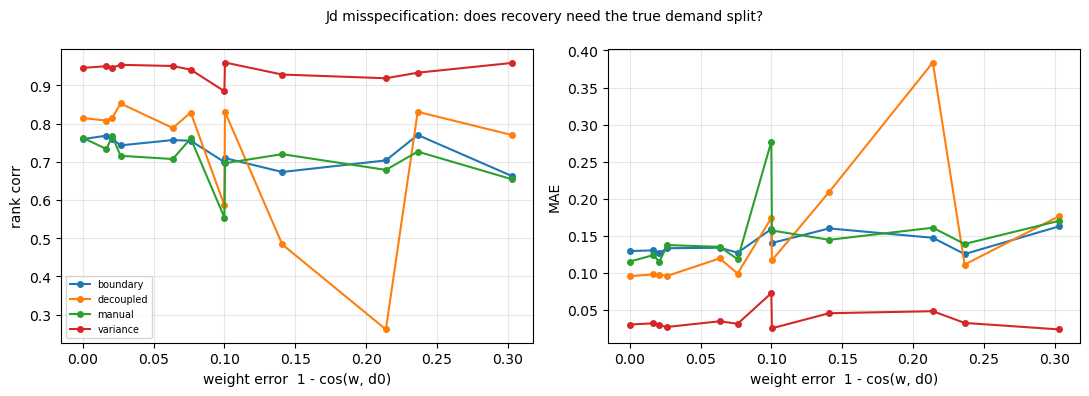

C:\Users\arthu\AppData\Local\Temp\ipykernel_18820\155686351.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,slope_rank_corr,sigma_min
placement,,
decoupled,-0.730,0.033
manual,-0.241,0.103
boundary,-0.235,0.168
variance,-0.032,0.279


A flat slope means the district Jacobian is dominated by BETWEEN-district routing, not the within-district split -- which is the result that makes this deployable. A steep slope means §13's 0.955 is an oracle number.


In [39]:
# =====================================================================
# 13c. Jd MISSPECIFICATION — how much does recovery depend on knowing
#      the within-district demand split?  `node_weights=d0` is the
#      oracle: the same proportional split that generates the data.
#      A client will not have it.
# =====================================================================
import networkx as nx
from scipy import stats as sps
import pathlib

N_WORLDS   = 20
RNG_SEEDS  = [0, 1, 2]
LOGN_SIGMA = [0.25, 0.50, 1.00]

d0_pos = d0.clip(lower=0.0)

def w_true():                        # oracle
    return d0_pos.copy()

def w_uniform():
    return pd.Series(1.0, index=d0.index)

def w_drift(wn, seed_node, hops=3, boost=20.0):
    """Post-drift concentration: BFS ball around drift_seed_node carries
    most of the district's demand move. Violates the proportional-split
    assumption district_jacobian() is built on."""
    G = wn.to_graph().to_undirected()
    w = d0_pos.copy()
    if seed_node in G:
        ball = nx.single_source_shortest_path_length(G, seed_node, cutoff=hops)
        for n, h in ball.items():
            if n in w.index:
                w[n] *= boost / (1.0 + h)
    return w

def w_lognormal(sigma, seed):
    rng = np.random.default_rng(seed)
    return d0_pos * np.exp(rng.normal(0, sigma, len(d0_pos)))

def w_err(w, districts):
    """Mean over districts of 1 - cos(w_used, w_true), restricted to each
    district's own nodes -- only the WITHIN-district split matters, the
    between-district scale cancels in a correlation."""
    e = []
    for d, nodes in districts["districts"].items():
        nn = [n for n in nodes if n in w.index and n in d0_pos.index]
        if len(nn) < 2:
            continue
        a, b = w.reindex(nn).fillna(0).to_numpy(), d0_pos.reindex(nn).to_numpy()
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        if na and nb:
            e.append(1.0 - float(a @ b) / (na * nb))
    return float(np.mean(e)) if e else np.nan

idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i + 1:]}

    seed_node = w.get("drift_seed_node")
    variants = {"true(d0)": w_true(), "uniform": w_uniform()}
    if isinstance(seed_node, str) and seed_node:
        variants["drift_concentrated"] = w_drift(a["wn"], seed_node)
    for sg in LOGN_SIGMA:
        for sd in RNG_SEEDS:
            variants[f"logn_s{sg:g}_{sd}"] = w_lognormal(sg, sd)

    for name, pl in PLACES.items():
        sens = [e for d in ds for e in pl[d]["flow"]]
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Y0 = s.pivot(index="step", columns="sensor", values="observed")
        Y0 = Y0.rename(columns={c: pipe_of(c, JD[name].index) for c in Y0.columns})
        Y0 = Y0[[c for c in JD[name].index if c in Y0.columns]]
        if Y0.shape[1] < len(ds):
            continue

        for vname, wv in variants.items():
            Jd = S.district_jacobian(sweep, DISTRICTS, sens,
                                     delta=DELTAS[1], node_weights=wv)
            q  = S.unmixing_quality(Jd)
            Dh = S.unmix_demands(Y0, Jd)
            est = {(x, y): float(np.corrcoef(Dh[x], Dh[y])[0, 1])
                   for i, x in enumerate(ds) for y in ds[i + 1:]}
            rows.append(dict(
                sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                placement=name, weights=vname,
                family=vname.split("_")[0] if vname.startswith("logn")
                       else vname,
                w_err=w_err(wv, DISTRICTS),
                sigma_min=q["sigma_min"], cond=q["cond"],
                rank_corr=sps.spearmanr([est[t] for t in truth],
                                        [truth[t] for t in truth]).statistic,
                mae=float(np.mean([abs(est[t] - truth[t]) for t in truth]))))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

W = pd.DataFrame(rows)

# ---- headline table: degradation vs the oracle -----------------------
agg_w = (W.groupby(["placement", "weights"])
         [["w_err", "sigma_min", "rank_corr", "mae"]].mean())
base = agg_w.xs("true(d0)", level="weights")["rank_corr"]
agg_w["drop_vs_oracle"] = (agg_w["rank_corr"]
                           - agg_w.index.get_level_values("placement").map(base))
display(agg_w.round(3))

# ---- the curve: recovery as a function of weight error ---------------
curve = (W.groupby(["placement", "weights"])[["w_err", "rank_corr", "mae"]]
         .mean().reset_index())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, g in curve.groupby("placement"):
    g = g.sort_values("w_err")
    ax[0].plot(g.w_err, g.rank_corr, "o-", ms=4, label=name)
    ax[1].plot(g.w_err, g.mae, "o-", ms=4, label=name)
ax[0].set_xlabel("weight error  1 - cos(w, d0)"); ax[0].set_ylabel("rank corr")
ax[1].set_xlabel("weight error  1 - cos(w, d0)"); ax[1].set_ylabel("MAE")
ax[0].legend(fontsize=7); ax[0].grid(alpha=.3); ax[1].grid(alpha=.3)
fig.suptitle("Jd misspecification: does recovery need the true demand split?",
             fontsize=10)
fig.tight_layout(); plt.show()

# ---- is the sensitivity itself placement-dependent? ------------------
sens_tbl = (curve.groupby("placement")
            .apply(lambda g: pd.Series({
                "slope_rank_corr": np.polyfit(g.w_err, g.rank_corr, 1)[0],
                "sigma_min": float(W[W.placement == g.name].sigma_min.mean())}))
            .sort_values("slope_rank_corr"))
display(sens_tbl.round(3))
print("A flat slope means the district Jacobian is dominated by BETWEEN-"
      "district routing, not the within-district split -- which is the "
      "result that makes this deployable. A steep slope means §13's 0.955 "
      "is an oracle number.")

In [18]:
import pathlib
import pandas as pd

NODES = {"District_A": 12, "District_B": 29, "District_C": 18,
         "District_D": 24, "District_E": 30}
RAMP_DAYS, DAYS_PER_MONTH = 42, 30
MONTH_COL = "drift_month"

W = P.discover_worlds(PROJ).query("usable")
rows = []
for _, world in W.iterrows():
    p = pathlib.Path(world["dir"]) / "clone/data/03_primary/gt_drift_schedule.csv"
    if not p.exists():
        print(f"  no schedule: {world['sim_hash'][:8]}")
        continue
    sch = pd.read_csv(p)
    if sch.empty:
        print(f"  EMPTY schedule: {world['sim_hash'][:8]} "
              f"({world['drift_district']}) -- front never advanced")
        continue
    tgt   = world["drift_district"]
    n_tot = NODES.get(tgt)
    first, last = int(sch[MONTH_COL].min()), int(sch[MONTH_COL].max())
    rows.append(dict(
        sim_hash=world["sim_hash"][:8], district=tgt,
        n_months=int(world["n_months"]), seed_node=world["drift_seed_node"],
        to_land_use=world["drift_to_land_use"],
        nodes_total=n_tot, nodes_converted=len(sch),
        onset=first, completion=last, span=last - first + 1,
        complete=(len(sch) == n_tot) if n_tot else None,
        stalled_months=(last - first + 1) - sch[MONTH_COL].nunique(),
        ramp_headroom=(int(world["n_months"]) - last) * DAYS_PER_MONTH - 1,
        ramp_clamped=((int(world["n_months"]) - last) * DAYS_PER_MONTH - 1) < RAMP_DAYS,
    ))

F = pd.DataFrame(rows)
print(f"\n{len(F)} worlds with a schedule")
display(F.sort_values(["district", "n_months", "sim_hash"]))
display(F.groupby("district").agg(
    n_worlds=("sim_hash", "size"), nodes_total=("nodes_total", "first"),
    converted_med=("nodes_converted", "median"),
    onset_med=("onset", "median"), completion_med=("completion", "median"),
    completion_max=("completion", "max"), all_complete=("complete", "all"),
    any_ramp_clamped=("ramp_clamped", "any"),
))


45 worlds with a schedule


,sim_hash,district,n_months,seed_node,to_land_use,nodes_total,nodes_converted,onset,completion,span,complete,stalled_months,ramp_headroom,ramp_clamped
1,125bcc3f,District_A,30,61,commercial,12,12,4,12,9,True,2,539,False
7,315e7ec9,District_A,30,61,industrial,12,12,4,12,9,True,2,539,False
14,59bb964e,District_A,30,61,industrial,12,12,4,12,9,True,2,539,False
24,766ba237,District_A,30,61,residential,12,12,4,12,9,True,2,539,False
30,98d1539c,District_A,30,61,residential,12,12,4,12,9,True,2,539,False
32,a3aba8f3,District_A,30,61,commercial,12,12,4,12,9,True,2,539,False
34,b2799422,District_A,30,61,industrial,12,12,4,12,9,True,2,539,False
43,eb97fb71,District_A,30,61,commercial,12,12,4,12,9,True,2,539,False
10,4bc7b2a4,District_B,30,93,commercial,29,29,4,22,19,True,4,239,False
12,4f816cfe,District_B,30,93,industrial,29,29,4,22,19,True,4,239,False


,n_worlds,nodes_total,converted_med,onset_med,completion_med,completion_max,all_complete,any_ramp_clamped
district,,,,,,,,
District_A,8,12,12.0,4.0,12.0,12,True,False
District_B,8,29,29.0,4.0,22.0,22,True,False
District_C,8,18,18.0,4.0,14.0,14,True,False
District_D,13,24,24.0,4.0,21.0,29,False,True
District_E,8,30,30.0,4.0,24.0,24,True,False


mean_d (positive only) 0.002481 | total 0.2779 m3/s | nonzero nodes 112


,x_mean_d,delta_m3s,pct_of_total_demand
0,0.01,0.0000,0.0089
1,0.05,0.0001,0.0446
2,0.10,0.0002,0.0893
3,0.25,0.0006,0.2232
4,0.50,0.0012,0.4464
5,1.00,0.0025,0.8929
6,2.00,0.0050,1.7857
7,5.00,0.0124,4.4643
8,10.00,0.0248,8.9286
9,100.50,0.2493,89.7321


  20/113 nodes
  40/113 nodes
  60/113 nodes
  80/113 nodes
  100/113 nodes


,n_solves,n_feasible,min_pressure,frac_feasible,n_sources_in_sweep
delta,,,,,
0.000025,113,113,35.564,1.0,113
0.000124,113,113,35.559,1.0,113
0.000248,113,113,35.553,1.0,113
0.000620,113,113,35.535,1.0,113
0.001240,113,113,35.504,1.0,113
0.002481,113,113,35.443,1.0,113
0.004962,113,113,35.321,1.0,113
0.012404,113,113,34.950,1.0,113
0.024808,113,113,34.321,1.0,113


frac_feasible < 1 => the maps at that level are computed on a DIFFERENT node set. Any comparison across such levels is survivorship, not physics.



,frac_pipes_reversed
delta,
0.000025,0.0000
0.000124,0.0001
0.000248,0.0002
0.000620,0.0003
0.001240,0.0004
0.002481,0.0009
0.004962,0.0023
0.012404,0.0058
0.024808,0.0116


,x_mean_d,median,p05,p95,frac_within_5pct
delta,,,,,
0.000025,0.01,0.9996,0.9116,1.1194,0.8319
0.000124,0.05,0.9999,0.9635,1.0377,0.9248
0.000248,0.10,0.9998,0.9723,1.0161,0.9475
0.000620,0.25,0.9998,0.9819,1.0102,0.9622
0.001240,0.50,0.9998,0.9902,1.0059,0.9749
0.002481,1.00,1.0000,1.0000,1.0000,0.9959
0.004962,2.00,1.0008,0.9910,1.0166,0.9622
0.012404,5.00,1.0036,0.9689,1.0603,0.9006
0.024808,10.00,1.0074,0.9427,1.1329,0.6148


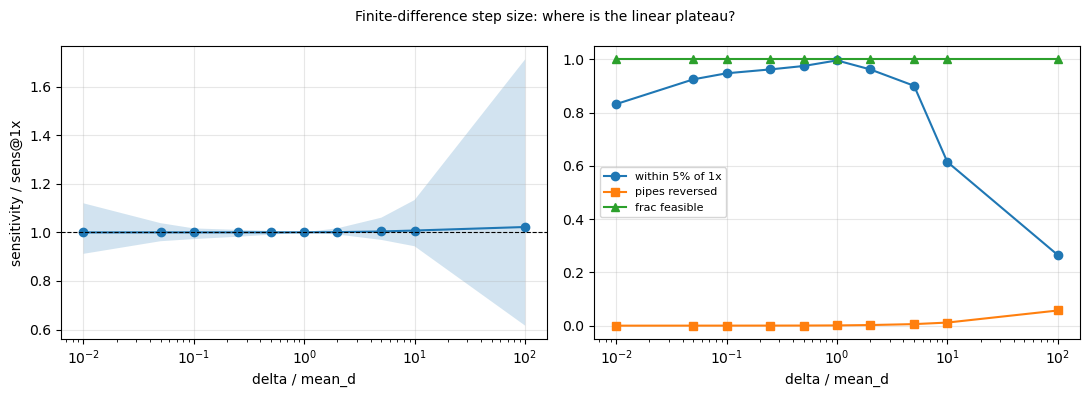

In [41]:
# =====================================================================
# DELTA LADDER — sensitivity is a finite difference, so the step size is
# a real parameter. Find the plateau where dQ/dD is flat in delta; that
# is the range over which one Jacobian describes the network.
#   too small -> solver precision / cancellation
#   too large -> nonlinearity, flow reversal, infeasibility
# All downstream stats are recomputed per level, so the choice of
# DELTAS[1] stops being an unexamined default.
# =====================================================================
import numpy as np, pandas as pd, pathlib
from scipy import stats as sps

# ---- corrected preamble for the delta ladder ------------------------
mean_d  = float(d0[d0 > 0].mean())          # matches cell 8
total_d = float(d0.sum())
LADDER  = np.array([0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 100.5])
DL      = LADDER * mean_d

print(f"mean_d (positive only) {mean_d:.6f} | total {total_d:.4f} m3/s | "
      f"nonzero nodes {(d0 > 0).sum()}")
display(pd.DataFrame({"x_mean_d": LADDER, "delta_m3s": DL,
                      "pct_of_total_demand": 100 * DL / total_d}).round(4))

# drop_infeasible=False so survivorship is VISIBLE (cell 8 uses the default True)
sweepL, diagL = S.perturbation_sweep(flat, list(DL), verbose=True,
                                     drop_infeasible=False)

# ---- 1. survivorship + feasibility audit ----------------------------
d = diagL[diagL["kind"] != "baseline"] if "kind" in diagL else diagL
aud = d.groupby("delta").agg(n_solves=("feasible", "size"),
                             n_feasible=("feasible", "sum"),
                             min_pressure=("min_pressure", "min"))
aud["frac_feasible"] = aud.n_feasible / aud.n_solves
aud["n_sources_in_sweep"] = sweepL.groupby("delta")["source_node"].nunique()
display(aud.round(3))
print("frac_feasible < 1 => the maps at that level are computed on a "
      "DIFFERENT node set. Any comparison across such levels is "
      "survivorship, not physics.\n")

# ---- 2. flow reversal: does the routing matrix itself change? -------
base_q = (sweepL[sweepL.quantity == "flowrate"]
          .drop_duplicates("target").set_index("target")["baseline"])
fl = sweepL[sweepL.quantity == "flowrate"].copy()
fl["q_pert"] = fl["baseline"] + fl["sensitivity"] * fl["delta"]
fl["reversed"] = np.sign(fl["q_pert"]) != np.sign(fl["baseline"])
rev = fl.groupby("delta")["reversed"].mean().rename("frac_pipes_reversed")
display(rev.to_frame().round(4))

# ---- 3. the plateau: sensitivity vs delta, per pipe ------------------
piv = (sweepL[sweepL.quantity == "flowrate"]
       .pivot_table(index=["source_node", "target"], columns="delta",
                    values="sensitivity"))
ref = DL[np.argmin(np.abs(LADDER - 1.0))]          # normalise at 1x mean_d
keep = piv[piv.abs().max(axis=1) > 1e-9]
ratio = keep.div(keep[ref], axis=0).abs()
plateau = pd.DataFrame({
    "x_mean_d": LADDER,
    "median": [float(ratio[c].median()) for c in piv.columns],
    "p05": [float(ratio[c].quantile(.05)) for c in piv.columns],
    "p95": [float(ratio[c].quantile(.95)) for c in piv.columns],
    "frac_within_5pct": [float(((ratio[c] - 1).abs() < .05).mean())
                         for c in piv.columns],
}, index=piv.columns)
display(plateau.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].fill_between(LADDER, plateau.p05, plateau.p95, alpha=.2)
ax[0].plot(LADDER, plateau["median"], "o-")
ax[0].axhline(1, ls="--", c="k", lw=.8); ax[0].set_xscale("log")
ax[0].set_xlabel("delta / mean_d"); ax[0].set_ylabel("sensitivity / sens@1x")
ax[1].plot(LADDER, plateau.frac_within_5pct, "o-", label="within 5% of 1x")
ax[1].plot(LADDER, rev.reindex(piv.columns).to_numpy(), "s-", label="pipes reversed")
ax[1].plot(LADDER, aud.frac_feasible.reindex(piv.columns).to_numpy(), "^-",
           label="frac feasible")
ax[1].set_xscale("log"); ax[1].set_xlabel("delta / mean_d"); ax[1].legend(fontsize=8)
for a in ax: a.grid(alpha=.3)
fig.suptitle("Finite-difference step size: where is the linear plateau?", fontsize=10)
fig.tight_layout(); plt.show()

In [46]:
# =====================================================================
# All statistics recomputed at every delta. The question is not "do the
# numbers move" but "over which range are they INVARIANT" -- that range
# is the method's operating envelope.
# =====================================================================
N_WORLDS = 20
idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
# physics checks + structure, per level
phys, chains = [], {}
for dl, x in zip(DL, LADDER):
    row = dict(x_mean_d=x, delta=dl)
    try:
        mb = S.check_mass_balance(sweepL[sweepL.delta == dl], flat)
        row["mass_bal_max_rel"] = float(mb["rel_error"].abs().max()) if len(mb) else np.nan
    except Exception as e:
        row["mass_bal_max_rel"] = np.nan; print(f"  mb @{x}x: {e}")
    try:
        rec = S.check_reciprocity(sweepL, flat, delta=dl)
        row["recip_rel_asym"] = float(rec["relative_asymmetry"].iloc[0]) if len(rec) else np.nan
        row["symmetric"] = bool(rec["symmetric"].iloc[0]) if len(rec) else None
    except Exception as e:
        row["recip_rel_asym"] = np.nan; print(f"  recip @{x}x: {e}")
    try:
        # linearity of this level against the 1x reference
        sub = sweepL[sweepL.delta.isin([dl, ref])]
        lin = S.check_linearity(sub, "flowrate") if dl != ref else pd.DataFrame()
        row["lin_ratio_med"] = float(lin["ratio_median"].iloc[0]) if len(lin) else np.nan
        row["lin_max_dev"] = float(lin["max_abs_dev_from_1"].iloc[0]) if len(lin) else np.nan
    except Exception as e:
        row["lin_ratio_med"] = np.nan; print(f"  lin @{x}x: {e}")
    try:
        Dm = S.supply_dependency(sweepL, DISTRICTS, flat, delta=dl)
        dp = S.directed_pairs(Dm)
        row["D_A_mean"] = float(Dm.loc["District_A"].mean())
        row["n_directed"] = int((dp["verdict"] != "mutual/parallel").sum())
        row["max_asym"] = float(dp["asymmetry"].max())
        chains[x] = dp[["district_a", "district_b", "verdict", "asymmetry"]]
    except Exception as e:
        print(f"  supply @{x}x: {e}")
    phys.append(row)

PH = pd.DataFrame(phys)
display(PH.round(6))

# does the recovered supply chain survive the step size?
for x, dp in chains.items():
    v = dp[dp.verdict != "mutual/parallel"]
    print(f"{x:>7}x mean_d: " + " | ".join(v.verdict.tolist()))

,x_mean_d,delta,mass_bal_max_rel,recip_rel_asym,symmetric,lin_ratio_med,lin_max_dev,D_A_mean,n_directed,max_asym
0,0.01,0.000025,0.000509,0.009317,True,1.000341,11.522663,0.999611,10,0.999491
1,0.05,0.000124,0.000509,0.001245,True,1.000138,19.779202,0.999593,10,0.999491
2,0.10,0.000248,0.000269,0.000934,True,1.000206,847.819885,0.999786,10,0.999731
3,0.25,0.000620,0.000029,0.000373,True,1.000192,5.863043,0.999977,10,0.999971
4,0.50,0.001240,0.000029,0.000311,True,1.000153,15.288889,0.999977,10,0.999971
5,1.00,0.002481,0.000029,0.000341,True,NaN,NaN,0.999977,10,0.999971
6,2.00,0.004962,0.000005,0.000602,True,1.000831,25.400002,0.999996,10,0.999995
7,5.00,0.012404,0.000005,0.001195,True,1.003511,111.211433,0.999996,10,0.999995
8,10.00,0.024808,0.000000,0.002364,True,1.006947,218.867859,1.000000,10,1.000000
9,100.50,0.249322,0.000000,0.011493,False,1.019698,856.273254,1.000000,10,1.000000


   0.01x mean_d: District_A upstream of District_B | District_A upstream of District_C | District_A upstream of District_D | District_A upstream of District_E | District_B upstream of District_C | District_B upstream of District_D | District_B upstream of District_E | District_C upstream of District_D | District_C upstream of District_E | District_E upstream of District_D
   0.05x mean_d: District_A upstream of District_B | District_A upstream of District_C | District_A upstream of District_D | District_A upstream of District_E | District_B upstream of District_C | District_B upstream of District_D | District_B upstream of District_E | District_C upstream of District_D | District_C upstream of District_E | District_E upstream of District_D
    0.1x mean_d: District_A upstream of District_B | District_A upstream of District_C | District_A upstream of District_D | District_A upstream of District_E | District_B upstream of District_C | District_B upstream of District_D | District_B upstre

In [48]:
# =====================================================================
# MAXWELL-BETTI SANITY CHECK
#  T1  the theorem, elementwise, with the precision floor as the yardstick
#  T2  mechanism: L = A G A^T is symmetric -> assembled directly from the
#      .inp, independent of the sweep. If T1 passes and T2 fails, the bug
#      is in the sweep, not in the physics.
#  T3  falsification: a check valve is NON-reciprocal, so inserting one
#      MUST break symmetry. A check that cannot fail proves nothing.
# =====================================================================
import numpy as np, pandas as pd, copy, wntr

DL_OPT = 0.5 * mean_d          # reciprocity-optimal step, per the ladder

# ---- T1. elementwise asymmetry vs the report-precision floor ---------
Pm = S.influence_matrix(sweepL, "pressure", delta=DL_OPT)
junc = [n for n in flat.junction_name_list if n in Pm.index and n in Pm.columns]
Pm = Pm.loc[junc, junc]
Asym = (Pm - Pm.T)

# EPANET writes pressure to 2 dp (mca). A finite difference of two rounded
# heads therefore carries +/- 0.005/delta of quantization -- and the
# asymmetry of a DIFFERENCE of two such, sqrt(2) more. This is the floor
# the measurement CANNOT go below; anything at it is a pass.
floor = np.sqrt(2) * 0.005 / DL_OPT
iu = np.triu_indices(len(junc), k=1)
a = np.abs(Asym.to_numpy()[iu])
print(f"delta {DL_OPT:.6f} | {len(a)} unordered pairs")
print(f"  quantization floor      : {floor:.4f}")
print(f"  max |asym|              : {a.max():.4f}  ({a.max()/floor:.2f}x floor)")
print(f"  median |asym|           : {np.median(a):.4f}")
print(f"  frac pairs within floor : {(a <= floor).mean():.4f}")
print(f"  relative asymmetry      : {a.max()/np.abs(Pm.to_numpy()).max():.2e}")

# Scaling test: quantization asymmetry ~ 1/delta, real asymmetry ~ delta.
# Which regime we are in is decidable, not a matter of opinion.
print("\n  asymmetry vs delta (falls as 1/delta => precision-limited):")
for x in [0.1, 0.25, 0.5, 1.0, 2.0, 5.0]:
    dl = x * mean_d
    Q = S.influence_matrix(sweepL, "pressure", delta=dl)
    Q = Q.loc[junc, junc]
    m = np.abs((Q - Q.T).to_numpy()[iu]).max()
    print(f"    {x:>5}x  max|asym| {m:9.4f}   x*|asym| {x*m:9.4f}")

# ---- T2. mechanism: assemble L = A G A^T from the .inp ---------------
# Independent of the sweep entirely: symmetry here is a property of the
# network file, so this isolates physics from measurement.
res = S.node_demands(flat)
sim = wntr.sim.EpanetSimulator(flat).run_sim()
q0 = sim.link["flowrate"].iloc[0]

nodes = {n: k for k, n in enumerate(flat.junction_name_list)}
rows = []
for name in flat.pipe_name_list:
    p = flat.get_link(name)
    if p.start_node_name not in nodes or p.end_node_name not in nodes:
        continue                      # reservoir/tank arcs: grounded
    C, D, Lp = p.roughness, p.diameter, p.length
    # Hazen-Williams resistance in SI (wntr convention)
    r = 10.67 * Lp / (C ** 1.852 * D ** 4.871)
    Q = abs(float(q0[name])) + 1e-12
    g = 1.0 / (1.852 * r * Q ** 0.852)         # linearized conductance
    rows.append((nodes[p.start_node_name], nodes[p.end_node_name], g))

N = len(nodes)
L = np.zeros((N, N))
for i, j, g in rows:
    L[i, i] += g; L[j, j] += g
    L[i, j] -= g; L[j, i] -= g

print(f"\nT2  assembled Laplacian {L.shape}")
print(f"  ||L - L^T||_max        : {np.abs(L - L.T).max():.3e}   (exact 0 expected)")
ev = np.linalg.eigvalsh(L)
print(f"  eigenvalues real       : True by eigvalsh; min {ev.min():.3e}")
print(f"  all conductances > 0   : {all(g > 0 for _, _, g in rows)}")
Lp_inv = np.linalg.pinv(L)
print(f"  ||L^+ - (L^+)^T||_max  : {np.abs(Lp_inv - Lp_inv.T).max():.3e}")

# Does the analytic influence matrix agree with the MEASURED one?
# Head sensitivity dH_j/dd_i = L^+_{ji}; pressure differs from head by a
# constant elevation, which drops out of a derivative.
common = [n for n in junc if n in nodes]
idx = [nodes[n] for n in common]
An = pd.DataFrame(Lp_inv[np.ix_(idx, idx)], index=common, columns=common)
Me = Pm.loc[common, common]
both = np.corrcoef(An.to_numpy().ravel(), Me.to_numpy().ravel())[0, 1]
print(f"  corr(analytic L^+, measured sweep) : {both:.4f}")

# ---- T3. falsification: a check valve MUST break reciprocity ---------
wn_cv = copy.deepcopy(flat)
victim = flat.pipe_name_list[len(flat.pipe_name_list) // 2]
wn_cv.get_link(victim).check_valve = True     # wntr >= 1.0; else initial_status
sw_cv, _ = S.perturbation_sweep(wn_cv, [DL_OPT], verbose=False,
                                drop_infeasible=False)
rc_cv = S.check_reciprocity(sw_cv, wn_cv, delta=DL_OPT)
rc_ok = S.check_reciprocity(sweepL, flat, delta=DL_OPT)
print(f"\nT3  check valve on pipe {victim}")
print(f"  reciprocal network : rel_asym {float(rc_ok.relative_asymmetry.iloc[0]):.2e}"
      f"  symmetric={bool(rc_ok.symmetric.iloc[0])}")
print(f"  with check valve   : rel_asym {float(rc_cv.relative_asymmetry.iloc[0]):.2e}"
      f"  symmetric={bool(rc_cv.symmetric.iloc[0])}")
print("  ^ if the second is not clearly larger, the check has no power and "
      "the 7.4e-04 pass means nothing.")

delta 0.001240 | 6328 unordered pairs
  quantization floor      : 5.7006
  max |asym|              : 0.0154  (0.00x floor)
  median |asym|           : 0.0031
  frac pairs within floor : 1.0000
  relative asymmetry      : 3.11e-04

  asymmetry vs delta (falls as 1/delta => precision-limited):
      0.1x  max|asym|    0.0461   x*|asym|    0.0046
     0.25x  max|asym|    0.0185   x*|asym|    0.0046
      0.5x  max|asym|    0.0154   x*|asym|    0.0077
      1.0x  max|asym|    0.0169   x*|asym|    0.0169
      2.0x  max|asym|    0.0300   x*|asym|    0.0600
      5.0x  max|asym|    0.0603   x*|asym|    0.3014

T2  assembled Laplacian (113, 113)
  ||L - L^T||_max        : 0.000e+00   (exact 0 expected)
  eigenvalues real       : True by eigvalsh; min 3.226e-15
  all conductances > 0   : True
  ||L^+ - (L^+)^T||_max  : 1.055e-10
  corr(analytic L^+, measured sweep) : -0.5696

T3  check valve on pipe 96
  reciprocal network : rel_asym 3.11e-04  symmetric=True
  with check valve   : rel_asym 3.1

In [49]:
# =====================================================================
# M1 recovery per placement per delta. The question is which range of
# delta leaves rank_corr / MAE INVARIANT -- that range is the operating
# envelope, and it decides whether DELTAS[1] was ever load-bearing.
# =====================================================================
import pathlib
import numpy as np, pandas as pd
from scipy import stats as sps

N_WORLDS = 20
ref = DL[np.argmin(np.abs(LADDER - 1.0))]
idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)

rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({dd: dm[[c for c in dm.columns
                                if c != "month" and n2d.get(c) == dd]].sum(axis=1)
                        for dd in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i + 1:]}

    for name, pl in PLACES.items():
        sens = [e for dd in ds for e in pl[dd]["flow"]]
        s = P.build_series(a["pressures"], a["flows"],
                           {dd: {"pressure": [], "flow": pl[dd]["flow"]} for dd in ds})
        s = s[s["kind"] == "flow"]
        Y = s.pivot(index="step", columns="sensor", values="observed")

        for dl, x in zip(DL, LADDER):
            Jd = S.district_jacobian(sweepL, DISTRICTS, sens,
                                     delta=dl, node_weights=d0)
            Ym = Y.rename(columns={c: pipe_of(c, Jd.index) for c in Y.columns})
            Ym = Ym[[c for c in Jd.index if c in Ym.columns]]
            if Ym.shape[1] < len(ds):
                continue
            Dh = S.unmix_demands(Ym, Jd)
            est = {(p, q): float(np.corrcoef(Dh[p], Dh[q])[0, 1])
                   for i, p in enumerate(ds) for q in ds[i + 1:]}
            qual = S.unmixing_quality(Jd)
            rows.append(dict(
                sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                placement=name, x_mean_d=x,
                sigma_min=qual["sigma_min"], cond=qual["cond"],
                rank_corr=sps.spearmanr([est[t] for t in truth],
                                        [truth[t] for t in truth]).statistic,
                mae=float(np.mean([abs(est[t] - truth[t]) for t in truth]))))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

R = pd.DataFrame(rows)
for metric in ["rank_corr", "mae", "sigma_min"]:
    print(f"\n=== {metric} ===")
    display(R.pivot_table(index="x_mean_d", columns="placement",
                          values=metric, aggfunc="mean").round(4))

# invariance band: where does recovery stay within noise of the 0.5x optimum?
piv = R.pivot_table(index=["sim_hash", "placement"], columns="x_mean_d",
                    values="rank_corr")
base = piv[0.5]
dev = piv.sub(base, axis=0).abs().groupby(level="placement").max()
print("\nmax |rank_corr - rank_corr@0.5x| per placement:")
display(dev.round(3))
print("Values under ~0.02 are inside the Spearman-over-10-pairs noise "
      "floor -> delta is not load-bearing over that range.")

  5/20
  10/20
  15/20
  20/20

=== rank_corr ===


placement,boundary,decoupled,manual,variance
x_mean_d,,,,
0.01,0.7418,0.8545,0.7642,0.9358
0.05,0.7430,0.8545,0.7636,0.9345
0.10,0.7424,0.8545,0.7624,0.9345
0.25,0.7424,0.8545,0.7630,0.9345
0.50,0.7424,0.8588,0.7630,0.9382
1.00,0.7424,0.8618,0.7630,0.9388
2.00,0.7455,0.8558,0.7630,0.9370
5.00,0.7485,0.8230,0.7642,0.9455
10.00,0.7594,0.8145,0.7630,0.9461



=== mae ===


placement,boundary,decoupled,manual,variance
x_mean_d,,,,
0.01,0.1321,0.0850,0.1143,0.0396
0.05,0.1327,0.0851,0.1148,0.0398
0.10,0.1326,0.0851,0.1148,0.0398
0.25,0.1326,0.0851,0.1147,0.0397
0.50,0.1325,0.0850,0.1146,0.0394
1.00,0.1324,0.0847,0.1143,0.0389
2.00,0.1320,0.0841,0.1142,0.0378
5.00,0.1310,0.0945,0.1138,0.0348
10.00,0.1293,0.0955,0.1152,0.0303



=== sigma_min ===


placement,boundary,decoupled,manual,variance
x_mean_d,,,,
0.01,0.1673,0.0398,0.0979,0.2804
0.05,0.1674,0.0399,0.0980,0.2804
0.10,0.1673,0.0399,0.0980,0.2804
0.25,0.1673,0.0399,0.0980,0.2805
0.50,0.1672,0.0403,0.0979,0.2806
1.00,0.1670,0.0403,0.0978,0.2807
2.00,0.1666,0.0373,0.0975,0.2810
5.00,0.1654,0.0270,0.0971,0.2820
10.00,0.1629,0.0255,0.0960,0.2837



max |rank_corr - rank_corr@0.5x| per placement:


x_mean_d,0.01,0.05,0.10,0.25,0.50,1.00,2.00,5.00,10.00,100.50
placement,,,,,,,,,,
boundary,0.024,0.012,0.000,0.000,0.0,0.000,0.048,0.048,0.109,0.339
decoupled,0.061,0.061,0.061,0.061,0.0,0.036,0.085,0.364,0.448,0.861
manual,0.024,0.024,0.012,0.000,0.0,0.000,0.000,0.073,0.061,0.352
variance,0.036,0.036,0.036,0.036,0.0,0.012,0.036,0.109,0.109,0.170


Values under ~0.02 are inside the Spearman-over-10-pairs noise floor -> delta is not load-bearing over that range.


In [63]:
# =====================================================================
# 13d. PINNED RECONCILIATION — baseline ladder and delta sweep in ONE
#      pass, on ONE explicitly pinned world set.
#
# Why one cell: the ladder and the delta sweep disagreed at matched delta
# (boundary 0.832 vs 0.759) despite bit-identical Jacobians. Computing
# both from the same loop removes the possibility of a plumbing
# difference, and the legacy arm below isolates the remaining candidate
# (world-set membership under .head(20)).
#
# Naming: results frames get 3-letter names. Single capitals are reserved
# for matrices -- reusing B/A/C/D/E as scratch clobbered both the ladder
# frame and the supply-dependency matrix earlier.
# =====================================================================
import pathlib
import numpy as np, pandas as pd
from scipy import stats as sps

# ---------------------------------------------------------------- 0. pin
# .head(N) is ORDER-dependent and the pool grew from 43 to 45 when the
# truncation probe ran, so "20 worlds" has meant different sets of 20 at
# different points. n_months==30 also excludes the 6-month resolution
# worlds (5/24 nodes converted) and the 36/48-month probe worlds.
POOL = (P.discover_worlds(PROJ)
        .query("usable and variant == 'baseline' and n_months == 30")
        .sort_values("sim_hash").reset_index(drop=True))
SIM_HASHES = POOL["sim_hash"].tolist()
WRL = POOL[POOL.sim_hash.isin(SIM_HASHES)].copy()

UNPINNED = (P.discover_worlds(PROJ).query("usable and variant=='baseline'")["sim_hash"].tolist())
print(f"eligible {len(POOL)} | pinned {len(WRL)}")
print(f"pinned == old head(20): {set(SIM_HASHES) == set(UNPINNED)}")
print(f"  dropped by pinning: {sorted(set(UNPINNED) - set(SIM_HASHES))}")
print(f"  added   by pinning: {sorted(set(SIM_HASHES) - set(UNPINNED))}")
print("\nSIM_HASHES =", SIM_HASHES)

DELTA_REF = 0.5 * mean_d          # reciprocity minimum (rel asym 3.1e-04)
print(f"\nDELTA_REF = {DELTA_REF:.6f}  ({DELTA_REF/float(d0.sum())*100:.3f}% of total demand)")

# ------------------------------------------------------------ 1. helpers
# Sign canonicalisation from the probe's BASELINE FLOW direction (physical),
# not from sign(Y.mean()) (unstable on low-flow pipes).
BASE_Q = (sweepL[sweepL["quantity"] == "flowrate"]
          .drop_duplicates("target").set_index("target")["baseline"])

def flips_for(cols):
    s = np.sign(BASE_Q.reindex(cols).fillna(1.0))
    s[s == 0] = 1.0
    return s

def district_mean(Y, pl, flip=True):
    """Averaging SIGNED flow sensors needs canonical orientation.
    Jacobian unmixing does NOT and must not get it -- Jd was built in the
    .inp's original orientation, so flipping Y without flipping Jd's rows
    breaks y = Jd @ d."""
    Yf = Y * flips_for(Y.columns) if flip else Y
    own = {d: [c for c in Yf.columns if c in set(pl[d]["flow"])] for d in ds}
    return pd.DataFrame({d: Yf[own[d]].mean(axis=1) for d in ds if own[d]})

def remove_pc1(Y):
    Z = ((Y - Y.mean()) / Y.std().replace(0, np.nan)).dropna(axis=1)
    U, sv, Vt = np.linalg.svd(Z.to_numpy(), full_matrices=False)
    return pd.DataFrame(Z.to_numpy() - (U[:, [0]] * sv[0] @ Vt[[0], :]),
                        index=Z.index, columns=Z.columns)

def remove_robust_cm(Y):
    """Geometric median common mode. Per timestep in 1-D the geometric
    median IS the median; regress it out per sensor, since a shared trunk
    does not load equally on every pipe."""
    Z = ((Y - Y.mean()) / Y.std().replace(0, np.nan)).dropna(axis=1)
    cm = Z.median(axis=1)
    v = float(cm.var()) or 1.0
    return pd.DataFrame({c: Z[c] - (np.cov(Z[c], cm)[0, 1] / v) * cm
                         for c in Z.columns}, index=Z.index)

def pairs_of(M):
    return {(x, y): float(np.corrcoef(M[x], M[y])[0, 1])
            for i, x in enumerate(ds) for y in ds[i + 1:]
            if x in M.columns and y in M.columns}

def pair_rank(est, truth):
    ks = [t for t in truth if np.isfinite(est.get(t, np.nan))]
    if len(ks) < 3:
        return np.nan, np.nan
    return (sps.spearmanr([est[t] for t in ks], [truth[t] for t in ks]).statistic,
            float(np.mean([abs(est[t] - truth[t]) for t in ks])))

# --------------------------------------------------------- 2. single loop
lad_rows, rec_rows = [], []
for k, (_, w) in enumerate(WRL.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = pairs_of(agg)

    for name, pl in PLACES.items():
        sens = [e for d in ds for e in pl[d]["flow"]]
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Yraw = s.pivot(index="step", columns="sensor", values="observed")

        def align(Jd):
            Ym = Yraw.rename(columns={c: pipe_of(c, Jd.index) for c in Yraw.columns})
            Ym = Ym[[c for c in Jd.index if c in Ym.columns]]
            return Ym if Ym.shape[1] >= len(ds) else None

        # ---- delta sweep: unmixed at every level ---------------------
        for dl, x in zip(DL, LADDER):
            Jd = S.district_jacobian(sweepL, DISTRICTS, sens,
                                     delta=dl, node_weights=d0)
            Ym = align(Jd)
            if Ym is None:
                continue
            rc, mae = pair_rank(pairs_of(S.unmix_demands(Ym, Jd)), truth)
            q = S.unmixing_quality(Jd)
            rec_rows.append(dict(sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                                 placement=name, x_mean_d=x, rank_corr=rc, mae=mae,
                                 sigma_min=q["sigma_min"], cond=q["cond"]))

        # ---- ladder at DELTA_REF: free methods vs unmixed ------------
        Jd_ref = S.district_jacobian(sweepL, DISTRICTS, sens,
                                     delta=DELTA_REF, node_weights=d0)
        Ym = align(Jd_ref)
        if Ym is None:
            continue
        Yf = Ym * flips_for(Ym.columns)
        ests = {
            "raw":         pairs_of(district_mean(Ym, pl)),
            "pc1_removed": pairs_of(district_mean(remove_pc1(Yf), pl, flip=False)),
            "robust_cm":   pairs_of(district_mean(remove_robust_cm(Yf), pl, flip=False)),
            "unmixed":     pairs_of(S.unmix_demands(Ym, Jd_ref)),
        }
        # legacy arm: the PREBUILT JD (delta = DELTAS[1] = 10x mean_d).
        # Reproduces the historical 0.832 if and only if the discrepancy
        # was world-set membership rather than delta or plumbing.
        if name in JD:
            Yl = align(JD[name])
            if Yl is not None:
                ests["unmixed_JDlegacy"] = pairs_of(S.unmix_demands(Yl, JD[name]))
        for meth, est in ests.items():
            rc, mae = pair_rank(est, truth)
            lad_rows.append(dict(sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                                 placement=name, method=meth,
                                 rank_corr=rc, mae=mae))
    if k % 5 == 0:
        print(f"  {k}/{len(WRL)}")

LAD = pd.DataFrame(lad_rows)
REC = pd.DataFrame(rec_rows)

# ------------------------------------------------------------ 3. tables
ORDER = ["raw", "pc1_removed", "robust_cm", "unmixed", "unmixed_JDlegacy"]
cols = [c for c in ORDER if c in set(LAD.method)]
print(f"\n=== ladder @ delta {DELTA_REF:.6f} ({len(LAD.sim_hash.unique())} worlds) ===")
for m in ["rank_corr", "mae"]:
    display(LAD.pivot_table(index="placement", columns="method",
                            values=m, aggfunc="mean")[cols].round(4))

print("\n=== delta sweep ===")
for m in ["rank_corr", "mae", "sigma_min"]:
    display(REC.pivot_table(index="x_mean_d", columns="placement",
                            values=m, aggfunc="mean").round(4))

# ---------------------------------------------------- 4. reconciliation
print("\n--- unmixed @ DELTA_REF: ladder vs sweep (must be identical) ---")
chk = (LAD[LAD.method == "unmixed"].set_index(["sim_hash", "placement"])["rank_corr"]
       .rename("ladder")
       .to_frame()
       .join(REC[REC.x_mean_d == 0.5]
             .set_index(["sim_hash", "placement"])["rank_corr"].rename("sweep")))
chk["diff"] = (chk.ladder - chk.sweep).abs()
print(f"max |diff| = {chk['diff'].max():.2e}  (nonzero => a real plumbing bug)")

print("\n--- legacy JD vs DELTA_REF, per placement ---")
lg = LAD[LAD.method.isin(["unmixed", "unmixed_JDlegacy"])].pivot_table(
    index="placement", columns="method", values="rank_corr", aggfunc="mean")
lg["legacy_minus_ref"] = lg["unmixed_JDlegacy"] - lg["unmixed"]
display(lg.round(4))
print("Historical section-13 values were boundary .832 / decoupled .892 /")
print("manual .801 / variance .955. If unmixed_JDlegacy now reproduces")
print("those, the earlier gap was WORLD-SET MEMBERSHIP. If it does not,")
print("the old numbers came from a world set we can no longer reconstruct.")

# ---- decisive test: unmixed vs best Jacobian-free, at DELTA_REF ------
piv = LAD.pivot_table(index=["sim_hash", "placement"], columns="method",
                      values="rank_corr")
free = [c for c in ["raw", "pc1_removed", "robust_cm"] if c in piv]
piv["best_free"] = piv[free].max(axis=1)
print("\n--- unmixed - best_free (clustered by consumption map below) ---")
for pl_name, g in piv.groupby(level="placement"):
    d = (g["unmixed"] - g["best_free"]).dropna()
    if len(d) < 3:
        continue
    t = sps.ttest_rel(g.loc[d.index, "unmixed"], g.loc[d.index, "best_free"])
    print(f"{pl_name:>10}: {d.mean():+.3f}  (paired p {t.pvalue:.4f}, n={len(d)})")

bym = (LAD[LAD.method.isin(["pc1_removed", "unmixed"])]
       .pivot_table(index=["cmap", "placement"], columns="method",
                    values="rank_corr", aggfunc="mean"))
bym["gain"] = bym["unmixed"] - bym["pc1_removed"]
display(bym.round(3))
gm = bym.groupby("cmap")["gain"].mean()
print(f"\nper-map mean gain (n={len(gm)} independent maps): "
      f"{', '.join(f'{v:+.3f}' for v in gm)}")
print(f"all positive: {bool((gm > 0).all())} | sign test p = {0.5**len(gm):.4f}")
print("^ THIS is the reportable statistic. The n=20 paired p treats "
      "correlated draws from 5 maps as independent.")

eligible 40 | pinned 40
pinned == old head(20): False
  dropped by pinning: ['021dcc84a2e2', '1d82532b441a', '249746c37b86', '4926bde37a8a', '5f1bf78de226', '6a888b279529', '74e5d158e6e7', '793748f7ed96', '7c18c548fcc4', '7feb875697f3', '987ddeef40de', '9ea580bce31a', '9fe2a5d417d1', 'adfe1b1ae73a', 'beec9360419c', 'dfa26387280a', 'e1743cff36a7', 'e582fe465af8', 'ebb32fa01ffc', 'fab3d88703fc']
  added   by pinning: []

SIM_HASHES = ['1044dfc21983', '125bcc3f1cb5', '13da76aafb4d', '19fc3635df2e', '23044627b86a', '232cbaa03583', '2db9c177a153', '315e7ec909a4', '39552bbd95b0', '4bc7b2a4af77', '4e6c4526b7ca', '4f816cfe3232', '527fdafd5640', '59bb964e8852', '5aa9b868ccf1', '5c6da4ac76fa', '613b7d8760b7', '62cff98c9fb5', '62fa14e1e7c4', '65d484908f41', '6c2b129c9f5c', '70fd6cfa961e', '766ba237d8ea', '885d89d84ddc', '8a4e7ce13a3d', '91d133ad279d', '98d1539ce4a0', 'a0a5406711ad', 'a3aba8f3787d', 'afcfa0871195', 'b2799422e6e4', 'c47fb4cf84f3', 'c9a0aed7d1e1', 'cc05b3cb461c', 'd4949f98c18f', 'd7

method,raw,pc1_removed,robust_cm,unmixed,unmixed_JDlegacy
placement,,,,,
boundary,0.2197,0.3891,0.1936,0.7094,0.7188
decoupled,0.3039,-0.0085,0.0394,0.8473,0.8236
manual,0.1867,0.2545,0.1700,0.7561,0.7606
variance,0.0067,0.0130,0.0345,0.9385,0.9452


method,raw,pc1_removed,robust_cm,unmixed,unmixed_JDlegacy
placement,,,,,
boundary,0.3918,0.7929,0.7900,0.1537,0.1512
decoupled,0.3245,0.7759,0.7022,0.0948,0.1045
manual,0.3950,0.8233,0.7616,0.1331,0.1334
variance,0.3924,0.7852,0.7242,0.0523,0.0390



=== delta sweep ===


placement,boundary,decoupled,manual,variance
x_mean_d,,,,
0.01,0.7152,0.8467,0.7606,0.9373
0.05,0.7097,0.8467,0.7579,0.9367
0.10,0.7094,0.8467,0.7548,0.9367
0.25,0.7094,0.8467,0.7552,0.9367
0.50,0.7094,0.8473,0.7561,0.9385
1.00,0.7091,0.8488,0.7567,0.9388
2.00,0.7109,0.8500,0.7585,0.9379
5.00,0.7136,0.8279,0.7600,0.9433
10.00,0.7188,0.8236,0.7606,0.9452


...


--- unmixed @ DELTA_REF: ladder vs sweep (must be identical) ---
max |diff| = 0.00e+00  (nonzero => a real plumbing bug)

--- legacy JD vs DELTA_REF, per placement ---


method,unmixed,unmixed_JDlegacy,legacy_minus_ref
placement,,,
boundary,0.7094,0.7188,0.0094
decoupled,0.8473,0.8236,-0.0236
manual,0.7561,0.7606,0.0045
variance,0.9385,0.9452,0.0067


Historical section-13 values were boundary .832 / decoupled .892 /
manual .801 / variance .955. If unmixed_JDlegacy now reproduces
those, the earlier gap was WORLD-SET MEMBERSHIP. If it does not,
the old numbers came from a world set we can no longer reconstruct.

--- unmixed - best_free (clustered by consumption map below) ---
  boundary: +0.223  (paired p 0.0057, n=40)
 decoupled: +0.464  (paired p 0.0000, n=40)
    manual: +0.338  (paired p 0.0000, n=40)
  variance: +0.767  (paired p 0.0000, n=40)


method                    pc1_removed  unmixed   gain
cmap           placement                             
LC_LR_LI_LR_LI boundary         0.359    0.936  0.577
               decoupled        0.150    0.817  0.667
               manual           0.309    0.921  0.612
               variance        -0.001    0.960  0.961
LI_LC_LR_LI_LC boundary         0.233    0.968  0.736
               decoupled        0.092    0.874  0.782
               manual           0.452    0.933  0.481
               variance        -0.223    0.961  1.184
LR_LC_LI_LR_LR boundary         0.463    0.104 -0.359
               decoupled       -0.196    0.776  0.972
               manual          -0.195    0.316  0.512
               variance        -0.078    0.859  0.937
LR_LI_LI_LC_LR boundary         0.502    0.829  0.327
               decoupled       -0.080    0.922  1.002
               manual           0.452    0.853  0.401
               variance         0.354    0.973  0.619


per-map mean gain (n=4 independent maps): +0.704, +0.796, +0.515, +0.588
all positive: True | sign test p = 0.0625
^ THIS is the reportable statistic. The n=20 paired p treats correlated draws from 5 maps as independent.
